<a href="https://colab.research.google.com/github/Tanxinru05/mem-gnn-rnn-continuous-prediction/blob/main/Interpretability_for_Power_Plant_DataSet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import requests
from tqdm import tqdm
import os
import pickle
from sklearn.preprocessing import StandardScaler # Changed to MinMaxScaler
from zipfile import ZipFile
from io import BytesIO

# --- Configuration ---
DATA_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00294/CCPP.zip'
TARGET_COLUMN = 'PE' # Net hourly electrical energy output

def create_tgat_data():
    print("--- 1. Loading Power Plant Data ---")
    if not os.path.exists('CCPP/Folds5x2_pp.xlsx'):
        print("Downloading data...")
        response = requests.get(DATA_URL); response.raise_for_status()
        with ZipFile(BytesIO(response.content)) as z: z.extractall()

    df = pd.read_excel('CCPP/Folds5x2_pp.xlsx')

    print("--- 2. Engineering Static Node Features ---")
    all_columns = df.columns.tolist()
    node_map = {name: i for i, name in enumerate(all_columns)}
    num_nodes = len(all_columns)

    node_features = np.zeros((num_nodes, 4))
    for i, col in enumerate(all_columns):
        node_features[i, 0] = df[col].mean(); node_features[i, 1] = df[col].std()
        node_features[i, 2] = df[col].min(); node_features[i, 3] = df[col].max()

    # --- CHANGE: Using MinMaxScaler for consistency ---
    node_features = StandardScaler().fit_transform(node_features)
    np.save('nodes_power_tgat.npy', node_features)

    print("--- 3. Creating Event Data and Adjacency List ---")
    df['ts'] = np.arange(len(df)) # Create a synthetic timestamp

    target_df = df[['ts', TARGET_COLUMN]].copy()
    target_df['node_id'] = node_map[TARGET_COLUMN]
    target_df.rename(columns={TARGET_COLUMN: 'demand'}, inplace=True)
    target_df[['ts', 'node_id', 'demand']].to_csv('events_power_tgat.csv', index=False)

    feature_df = df.drop(columns=[TARGET_COLUMN])
    adj_list = {node_map[TARGET_COLUMN]: []}

    for col in tqdm(feature_df.drop(columns=['ts']).columns, desc="Building Adjacency List"):
        feature_node_id = node_map[col]
        for row in feature_df[['ts', col]].itertuples():
            adj_list[node_map[TARGET_COLUMN]].append((feature_node_id, row.ts))

    with open('adj_list_power_tgat.pkl', 'wb') as f:
        pickle.dump(adj_list, f)
    print("\nPreprocessing complete for TGAT models.")

if __name__ == '__main__':
    create_tgat_data()

--- 1. Loading Power Plant Data ---
--- 2. Engineering Static Node Features ---
--- 3. Creating Event Data and Adjacency List ---


Building Adjacency List: 100%|██████████| 4/4 [00:00<00:00, 99.33it/s]


Preprocessing complete for TGAT models.


--- 🚀 Running SHAP Analysis ---
Using device: cpu


--- 🧐 Starting SHAP Interpretability Analysis --- 
✅ Best model loaded for analysis.
--- 🧠 Explaining 50 test samples one by one (this may take a while)... ---


SHAP Progress:   0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

SHAP Progress:   2%|▏         | 1/50 [00:07<05:48,  7.11s/it]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

SHAP Progress:  98%|█████████▊| 49/50 [06:13<00:07,  7.81s/it]

  0%|          | 0/1 [00:00<?, ?it/s]

SHAP Progress: 100%|██████████| 50/50 [06:20<00:00,  7.61s/it]


✅ SHAP analysis complete. Generating summary plot...


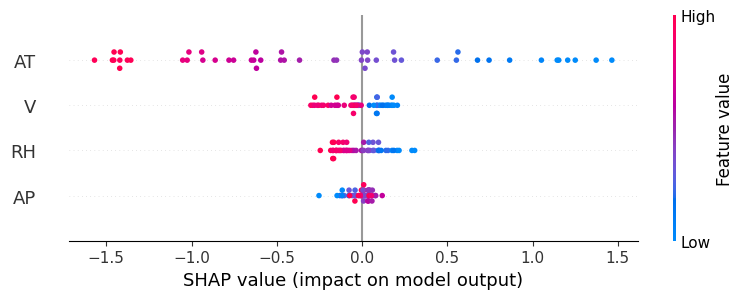

✅ SHAP summary plot saved to shap_summary.png.


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Subset
from sklearn.preprocessing import StandardScaler
import os
import pickle
from tqdm import tqdm
import sys
import shap
import matplotlib.pyplot as plt
import warnings

# --- Configuration ---
warnings.filterwarnings('ignore')
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- 🚀 Running SHAP Analysis ---")
print(f"Using device: {DEVICE}")

# Model and Data Hyperparameters (must match the trained model)
HIDDEN_DIM = 128
N_HEADS = 4
N_LAYERS = 2
DROPOUT_RATE = 0.2
BATCH_SIZE = 256
NUM_NEIGHBORS = 4

# --- Helper Classes & Model Definition (Required to load the model) ---

class NeighborFinder:
    """Finds temporal neighbors for a given set of nodes."""
    def __init__(self, adj_list):
        self.adj_list = adj_list
    def get_temporal_neighbor(self, src_idx_l, cut_time_l, num_neighbors=20):
        out_ngh_node_batch = np.zeros((len(src_idx_l), num_neighbors)).astype(np.int64)
        out_ngh_ts_batch = np.zeros((len(src_idx_l), num_neighbors)).astype(np.float64)
        for i, (src_idx, cut_time) in enumerate(zip(src_idx_l, cut_time_l)):
            neighbors = self.adj_list.get(src_idx, [])
            recent_neighbors = sorted([n for n in neighbors if n[1] <= cut_time], key=lambda x: x[1], reverse=True)[:num_neighbors]
            if recent_neighbors:
                out_ngh_node_batch[i, :len(recent_neighbors)] = [x[0] for x in recent_neighbors]
                out_ngh_ts_batch[i, :len(recent_neighbors)] = [x[1] for x in recent_neighbors]
        return out_ngh_node_batch, out_ngh_ts_batch

class SinusoidalTimeEncode(nn.Module):
    """Encodes time using sinusoidal functions."""
    def __init__(self, dimension):
        super().__init__()
        self.dimension = dimension
    def forward(self, t):
        t = t.unsqueeze(dim=-1)
        div = torch.exp(torch.arange(0, self.dimension, 2, device=DEVICE).float() * -(np.log(10000.0) / self.dimension))
        pe = torch.zeros(*t.shape[:2], self.dimension, device=DEVICE)
        pe[..., 0::2] = torch.sin(t * div)
        pe[..., 1::2] = torch.cos(t * div)
        return pe

class TemporalAttentionLayer(nn.Module):
    """Computes temporal attention over neighbors."""
    def __init__(self, feat_dim, n_heads, dropout):
        super().__init__()
        self.h, self.d = n_heads, feat_dim // n_heads
        self.q_proj, self.k_proj, self.v_proj = (nn.Linear(feat_dim, feat_dim) for _ in range(3))
        self.t_proj = nn.Linear(feat_dim, feat_dim)
        self.o_proj = nn.Linear(feat_dim, feat_dim)
        self.dropout = nn.Dropout(dropout)
    def forward(self, src_feat, ngh_feat, t_enc):
        b, n_ngh, _ = ngh_feat.size()
        q = self.q_proj(src_feat).view(b, self.h, self.d).unsqueeze(2)
        k = self.k_proj(ngh_feat).view(b, n_ngh, self.h, self.d).permute(0, 2, 1, 3)
        v = self.v_proj(ngh_feat).view(b, n_ngh, self.h, self.d).permute(0, 2, 1, 3)
        t = self.t_proj(t_enc).view(b, n_ngh, self.h, self.d).permute(0, 2, 1, 3)
        scores = torch.sum((q * k) + t, dim=-1) / np.sqrt(self.d)
        attn = torch.softmax(scores, dim=-1)
        out = torch.sum(attn.unsqueeze(-1) * v, dim=2)
        return self.dropout(self.o_proj(out.view(b, -1)))

class TGAT_MHSA_BiLSTM(nn.Module):
    """The main Hybrid Graph Model."""
    def __init__(self, neighbor_finder, node_features, feat_dim, n_layers, n_heads, dropout, bilstm_h, num_direct_features):
        super().__init__()
        self.neighbor_finder = neighbor_finder
        self.register_buffer('node_features', node_features)
        self.embed_dim = bilstm_h * 2
        self.feat_proj = nn.Linear(feat_dim, self.embed_dim)
        self.time_enc = SinusoidalTimeEncode(self.embed_dim)
        self.attn_layers = nn.ModuleList([TemporalAttentionLayer(self.embed_dim, n_heads, dropout) for _ in range(n_layers)])
        self.norm_layers = nn.ModuleList([nn.LayerNorm(self.embed_dim) for _ in range(n_layers)])
        self.mhsa = nn.MultiheadAttention(bilstm_h * 2, num_heads=n_heads, batch_first=True, dropout=dropout)
        self.bilstm = nn.LSTM(bilstm_h * 2, bilstm_h, batch_first=True, bidirectional=True)
        self.seq_norm = nn.LayerNorm(bilstm_h * 2)
        self.direct_feature_proj = nn.Sequential(nn.Linear(num_direct_features, bilstm_h), nn.ReLU(), nn.Linear(bilstm_h, bilstm_h * 2))
        self.reg_head = nn.Sequential(nn.Linear(bilstm_h * 4, bilstm_h * 2), nn.GELU(), nn.Dropout(dropout), nn.Linear(bilstm_h * 2, bilstm_h), nn.GELU(), nn.Dropout(dropout), nn.Linear(bilstm_h, 1))

    def forward(self, src_nodes, timestamps, direct_features):
        src_feat = self.feat_proj(self.node_features[src_nodes])
        layer_outputs = []
        for i in range(len(self.attn_layers)):
            ngh_idx, ngh_ts = self.neighbor_finder.get_temporal_neighbor(src_nodes.cpu().numpy(), timestamps.cpu().numpy(), NUM_NEIGHBORS)
            ngh_idx_t = torch.from_numpy(ngh_idx).long().to(DEVICE)
            ngh_feat = self.feat_proj(self.node_features[ngh_idx_t.flatten()]).view(len(src_nodes), NUM_NEIGHBORS, -1)
            t_deltas = timestamps.unsqueeze(1) - torch.from_numpy(ngh_ts).float().to(DEVICE)
            t_enc = self.time_enc(t_deltas)
            mask = (ngh_idx_t != 0).unsqueeze(-1)
            agg_embed = self.attn_layers[i](src_feat, ngh_feat * mask, t_enc)
            src_feat = self.norm_layers[i](agg_embed + src_feat)
            layer_outputs.append(src_feat)

        tgat_sequence = torch.stack(layer_outputs, dim=1)
        mhsa_out, _ = self.mhsa(tgat_sequence, tgat_sequence, tgat_sequence)
        mhsa_sequence = self.seq_norm(tgat_sequence + mhsa_out)
        bilstm_out, _ = self.bilstm(mhsa_sequence)

        graph_representation = torch.mean(bilstm_out, dim=1)
        direct_representation = self.direct_feature_proj(direct_features)

        # This concatenation is where the original error occurred
        combined_representation = torch.cat([graph_representation, direct_representation], dim=1)

        return self.reg_head(combined_representation)


# --- <<< CORRECTED SHAP ANALYSIS FUNCTION >>> ---
def analyze_shap_interpretability(model_path, model_args, test_loader, train_ds, direct_feature_names):
    """
    Loads a trained model and performs SHAP analysis to interpret feature importance.
    """
    print("\n\n" + "="*80 + "\n--- 🧐 Starting SHAP Interpretability Analysis --- \n" + "="*80)

    # 1. Load the best model
    model = TGAT_MHSA_BiLSTM(**model_args).to(DEVICE)
    try:
        model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    except FileNotFoundError:
        print(f"❌ ERROR: Model file not found at '{model_path}'.")
        print("Please ensure the model has been trained and the file is in the correct directory.")
        sys.exit()

    model.eval()
    print("✅ Best model loaded for analysis.")

    # 2. Prepare data for SHAP
    # A. Get a batch of test data to explain.
    test_nodes, test_ts, test_direct, _ = next(iter(test_loader))

    # B. Use a sample of the training data as the background reference.
    _, _, background_direct, _ = next(iter(DataLoader(train_ds, batch_size=100, shuffle=True)))
    # Summarize the background data for efficiency
    background_summary = shap.sample(background_direct.cpu().numpy(), 30)

    # C. Explain a smaller subset of the test data, as explaining each sample is computationally intensive.
    num_samples_to_explain = 50
    data_to_explain = test_direct[:num_samples_to_explain]
    nodes_to_explain = test_nodes[:num_samples_to_explain]
    ts_to_explain = test_ts[:num_samples_to_explain]

    # 3. Run SHAP Analysis with the Corrected Wrapper
    all_shap_values = []
    print(f"--- 🧠 Explaining {num_samples_to_explain} test samples one by one (this may take a while)... ---")

    # D. Loop through each sample to create an explanation
    for i in tqdm(range(num_samples_to_explain), desc="SHAP Progress"):
        # This wrapper is created for EACH sample. It uses the node and timestamp
        # for the i-th sample, ensuring batch sizes always match.
        def shap_prediction_wrapper(direct_features_numpy):
            num_perturbations = direct_features_numpy.shape[0]

            # Repeat the single node_id and timestamp to match SHAP's perturbation batch size
            nodes_batch = nodes_to_explain[i].repeat(num_perturbations).to(DEVICE)
            ts_batch = ts_to_explain[i].repeat(num_perturbations).to(DEVICE)
            direct_features_batch = torch.from_numpy(direct_features_numpy).float().to(DEVICE)

            with torch.no_grad():
                predictions = model(nodes_batch, ts_batch, direct_features_batch)

            return predictions.cpu().numpy().flatten()

        # E. Create an explainer and calculate SHAP values for the single sample
        explainer = shap.KernelExplainer(shap_prediction_wrapper, background_summary)
        shap_values_instance = explainer.shap_values(data_to_explain[i:i+1].cpu().numpy(), nsamples=50)
        all_shap_values.append(shap_values_instance)

    # F. Combine the results into a single array for plotting
    shap_values = np.concatenate(all_shap_values, axis=0)

    # G. Generate and save the summary plot
    print("✅ SHAP analysis complete. Generating summary plot...")
    plt.figure()
    shap.summary_plot(shap_values, features=data_to_explain.cpu().numpy(), feature_names=direct_feature_names, show=False)
    plt.savefig("shap_summary.png", bbox_inches='tight')
    plt.show()
    plt.close()
    print("✅ SHAP summary plot saved to shap_summary.png.")


if __name__ == '__main__':
    # --- Data Loading and Preparation ---
    try:
        node_features_array = np.load('nodes_power_tgat.npy')
        with open('adj_list_power_tgat.pkl', 'rb') as f:
            adj_list = pickle.load(f)
        original_df = pd.read_excel('CCPP/Folds5x2_pp.xlsx')
    except FileNotFoundError as e:
        print(f"❌ ERROR: Data file not found: {e.filename}.")
        print("Please ensure your data files ('nodes_power_tgat.npy', 'adj_list_power_tgat.pkl', 'CCPP/Folds5x2_pp.xlsx') are in the same directory.")
        sys.exit()

    direct_feature_names = ['AT', 'V', 'AP', 'RH']
    target = original_df[['PE']].values
    direct_features = original_df[direct_feature_names].values

    feature_scaler = StandardScaler().fit(direct_features)
    target_scaler = StandardScaler().fit(target)

    direct_features_scaled = feature_scaler.transform(direct_features)
    target_scaled = target_scaler.transform(target)

    node_ids = np.full(len(original_df), 4) # Assuming node 4 is the relevant one as in the original script
    timestamps = np.arange(len(original_df))

    node_features = torch.tensor(node_features_array, dtype=torch.float32)

    # Create Datasets and Dataloaders
    full_ds = TensorDataset(
        torch.from_numpy(node_ids).long(),
        torch.from_numpy(timestamps).float(),
        torch.from_numpy(direct_features_scaled).float(),
        torch.from_numpy(target_scaled).float()
    )

    train_size = int(len(original_df) * 0.7)
    val_size = int(len(original_df) * 0.15)

    train_ds = Subset(full_ds, range(train_size))
    test_ds = Subset(full_ds, range(train_size + val_size, len(original_df)))

    # We only need the test_loader and train_ds (for background) for this script
    test_loader = DataLoader(test_ds, BATCH_SIZE, shuffle=False)

    neighbor_finder = NeighborFinder(adj_list)
    feat_dim = node_features.shape[1]

    # --- Model Configuration ---
    model_name = "Hybrid_TGAT_MHSA_BiLSTM"
    model_args = {
        'neighbor_finder': neighbor_finder,
        'node_features': node_features,
        'feat_dim': feat_dim,
        'n_layers': N_LAYERS,
        'n_heads': N_HEADS,
        'dropout': DROPOUT_RATE,
        'bilstm_h': HIDDEN_DIM,
        'num_direct_features': direct_features.shape[1]
    }

    # --- Execute the SHAP Analysis ---
    analyze_shap_interpretability(
        model_path=f'best_{model_name}_1.pth',
        model_args=model_args,
        test_loader=test_loader,
        train_ds=train_ds,
        direct_feature_names=direct_feature_names
    )

--- 🚀 Running Model Interpretability Analysis ---
Using device: cpu


--- 🧐 Starting Full Interpretability Analysis --- 
✅ Best model loaded for analysis.

--- 🧠 Running SHAP Analysis ---
Explaining 50 test samples one by one...


SHAP Progress:   0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

SHAP Progress:   2%|▏         | 1/50 [00:06<05:20,  6.54s/it]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

SHAP Progress:  98%|█████████▊| 49/50 [05:50<00:06,  6.97s/it]

  0%|          | 0/1 [00:00<?, ?it/s]

SHAP Progress: 100%|██████████| 50/50 [05:57<00:00,  7.16s/it]


✅ SHAP analysis complete. Generating summary plot...


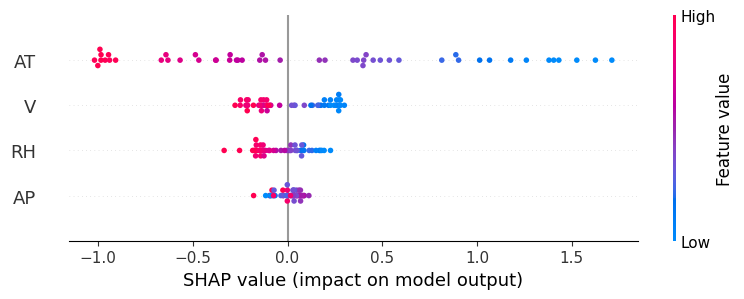



--- 🔢 Quantitative Dimensionality Analysis --- 
This analysis provides objective proof of how the model handles high dimensionality.

Analyzed 1024 samples.
Original direct feature dimension: 4
Learned embedding dimension: 512

--- A. Intrinsic Dimensionality (Proof of Compression) ---
👉 Number of components to explain 95% variance (d95): 7

-------------------- INSIGHT --------------------
The model's learned representation is highly efficient. The PCA results show that the essential information
from the 512-dimensional embedding space can be compressed into just 7 dimensions while retaining 95% of its variance.
This is strong quantitative proof that the model is performing effective dimensionality reduction.
-------------------------------------------------


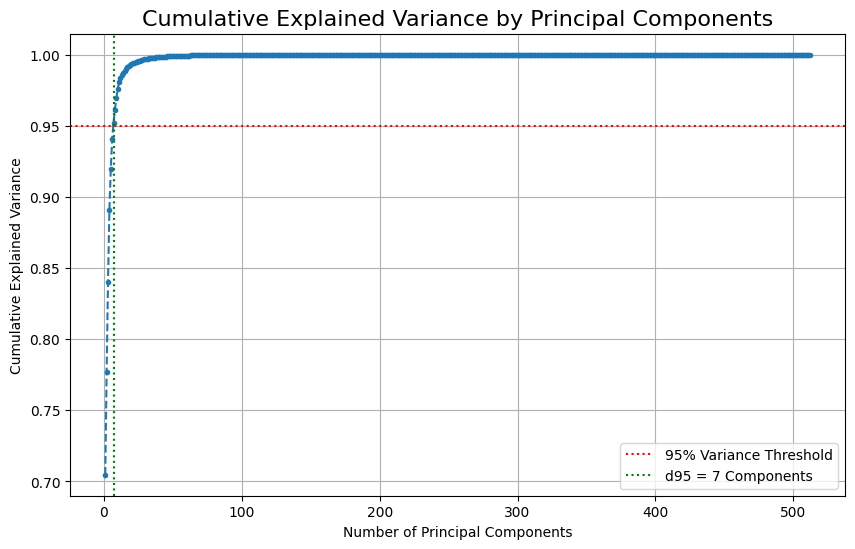


--- B. Neighborhood Preservation (Trustworthiness) ---
👉 Trustworthiness score (k=10): 0.9971

-------------------- INSIGHT --------------------
This score proves the model's compression was intelligent, not just lossy. A high score (close to 1.0)
means that data points that were neighbors in the original space are still neighbors in the new, compressed space.
Our score of 0.9971 shows the model preserved the data's essential structure, creating a more coherent representation.
-------------------------------------------------

--- 結論 (Conclusion) ---
✅ In summary, these metrics demonstrate that the model successfully resolves the issues of high dimensionality.
   1. PCA proves it **compresses** the data efficiently.
   2. Trustworthiness proves it does so in a **meaningful** way.


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Subset
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import trustworthiness
import os
import pickle
from tqdm import tqdm
import sys
import shap
import matplotlib.pyplot as plt
import warnings

# --- Configuration ---
warnings.filterwarnings('ignore')
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- 🚀 Running Model Interpretability Analysis ---")
print(f"Using device: {DEVICE}")

# Model and Data Hyperparameters (must match the trained model)
HIDDEN_DIM = 128
N_HEADS = 4
N_LAYERS = 2
DROPOUT_RATE = 0.2
BATCH_SIZE = 256
NUM_NEIGHBORS = 4

# --- Helper Classes & Model Definition ---
class NeighborFinder:
    def __init__(self, adj_list):
        self.adj_list = adj_list
    def get_temporal_neighbor(self, src_idx_l, cut_time_l, num_neighbors=20):
        out_ngh_node_batch = np.zeros((len(src_idx_l), num_neighbors)).astype(np.int64)
        out_ngh_ts_batch = np.zeros((len(src_idx_l), num_neighbors)).astype(np.float64)
        for i, (src_idx, cut_time) in enumerate(zip(src_idx_l, cut_time_l)):
            neighbors = self.adj_list.get(src_idx, [])
            recent_neighbors = sorted([n for n in neighbors if n[1] <= cut_time], key=lambda x: x[1], reverse=True)[:num_neighbors]
            if recent_neighbors:
                out_ngh_node_batch[i, :len(recent_neighbors)] = [x[0] for x in recent_neighbors]
                out_ngh_ts_batch[i, :len(recent_neighbors)] = [x[1] for x in recent_neighbors]
        return out_ngh_node_batch, out_ngh_ts_batch

class SinusoidalTimeEncode(nn.Module):
    def __init__(self, dimension):
        super().__init__()
        self.dimension = dimension
    def forward(self, t):
        t = t.unsqueeze(dim=-1)
        div = torch.exp(torch.arange(0, self.dimension, 2, device=DEVICE).float() * -(np.log(10000.0) / self.dimension))
        pe = torch.zeros(*t.shape[:2], self.dimension, device=DEVICE)
        pe[..., 0::2] = torch.sin(t * div)
        pe[..., 1::2] = torch.cos(t * div)
        return pe

class TemporalAttentionLayer(nn.Module):
    def __init__(self, feat_dim, n_heads, dropout):
        super().__init__()
        self.h, self.d = n_heads, feat_dim // n_heads
        self.q_proj, self.k_proj, self.v_proj = (nn.Linear(feat_dim, feat_dim) for _ in range(3))
        self.t_proj = nn.Linear(feat_dim, feat_dim)
        self.o_proj = nn.Linear(feat_dim, feat_dim)
        self.dropout = nn.Dropout(dropout)
    def forward(self, src_feat, ngh_feat, t_enc):
        b, n_ngh, _ = ngh_feat.size()
        q = self.q_proj(src_feat).view(b, self.h, self.d).unsqueeze(2)
        k = self.k_proj(ngh_feat).view(b, n_ngh, self.h, self.d).permute(0, 2, 1, 3)
        v = self.v_proj(ngh_feat).view(b, n_ngh, self.h, self.d).permute(0, 2, 1, 3)
        t = self.t_proj(t_enc).view(b, n_ngh, self.h, self.d).permute(0, 2, 1, 3)
        scores = torch.sum((q * k) + t, dim=-1) / np.sqrt(self.d)
        attn = torch.softmax(scores, dim=-1)
        out = torch.sum(attn.unsqueeze(-1) * v, dim=2)
        return self.dropout(self.o_proj(out.view(b, -1)))

# <<< MODIFIED: Model now has a flag to return embeddings and a bug fix >>>
class TGAT_MHSA_BiLSTM(nn.Module):
    def __init__(self, neighbor_finder, node_features, feat_dim, n_layers, n_heads, dropout, bilstm_h, num_direct_features):
        super().__init__()
        self.neighbor_finder = neighbor_finder
        self.register_buffer('node_features', node_features)
        self.embed_dim = bilstm_h * 2
        self.feat_proj = nn.Linear(feat_dim, self.embed_dim)
        self.time_enc = SinusoidalTimeEncode(self.embed_dim)
        self.attn_layers = nn.ModuleList([TemporalAttentionLayer(self.embed_dim, n_heads, dropout) for _ in range(n_layers)])
        self.norm_layers = nn.ModuleList([nn.LayerNorm(self.embed_dim) for _ in range(n_layers)])
        self.mhsa = nn.MultiheadAttention(bilstm_h * 2, num_heads=n_heads, batch_first=True, dropout=dropout)
        self.bilstm = nn.LSTM(bilstm_h * 2, bilstm_h, batch_first=True, bidirectional=True)
        self.seq_norm = nn.LayerNorm(bilstm_h * 2)
        self.direct_feature_proj = nn.Sequential(nn.Linear(num_direct_features, bilstm_h), nn.ReLU(), nn.Linear(bilstm_h, bilstm_h * 2))
        self.reg_head = nn.Sequential(nn.Linear(bilstm_h * 4, bilstm_h * 2), nn.GELU(), nn.Dropout(dropout), nn.Linear(bilstm_h * 2, bilstm_h), nn.GELU(), nn.Dropout(dropout), nn.Linear(bilstm_h, 1))

    def forward(self, src_nodes, timestamps, direct_features, return_embedding=False):
        src_feat = self.feat_proj(self.node_features[src_nodes])
        layer_outputs = []
        for i in range(len(self.attn_layers)):
            ngh_idx, ngh_ts = self.neighbor_finder.get_temporal_neighbor(src_nodes.cpu().numpy(), timestamps.cpu().numpy(), NUM_NEIGHBORS)
            ngh_idx_t = torch.from_numpy(ngh_idx).long().to(DEVICE)
            ngh_feat = self.feat_proj(self.node_features[ngh_idx_t.flatten()]).view(len(src_nodes), NUM_NEIGHBORS, -1)
            t_deltas = timestamps.unsqueeze(1) - torch.from_numpy(ngh_ts).float().to(DEVICE)
            t_enc = self.time_enc(t_deltas)
            mask = (ngh_idx_t != 0).unsqueeze(-1)
            agg_embed = self.attn_layers[i](src_feat, ngh_feat * mask, t_enc)
            src_feat = self.norm_layers[i](agg_embed + src_feat)
            layer_outputs.append(src_feat)

        tgat_sequence = torch.stack(layer_outputs, dim=1)

        # BUG FIX: Correctly get output from mhsa which returns a tuple
        mhsa_out = self.mhsa(tgat_sequence, tgat_sequence, tgat_sequence)[0]

        mhsa_sequence = self.seq_norm(tgat_sequence + mhsa_out)
        bilstm_out, _ = self.bilstm(mhsa_sequence)

        graph_representation = torch.mean(bilstm_out, dim=1)
        direct_representation = self.direct_feature_proj(direct_features)

        combined_representation = torch.cat([graph_representation, direct_representation], dim=1)

        if return_embedding:
            return combined_representation

        return self.reg_head(combined_representation)


# <<< NEW: Quantitative Dimensionality Analysis Function >>>
def analyze_dimensionality_quantitatively(model, test_loader, direct_feature_names):
    print("\n\n" + "="*50 + "\n--- 🔢 Quantitative Dimensionality Analysis --- \n" + "="*50)
    print("This analysis provides objective proof of how the model handles high dimensionality.")

    embeddings_list = []
    raw_features_list = []
    with torch.no_grad():
        for nodes, ts, direct_feats, _ in test_loader:
            embeddings_list.append(model(nodes.to(DEVICE), ts.to(DEVICE), direct_feats.to(DEVICE), return_embedding=True).cpu())
            raw_features_list.append(direct_feats.cpu())
            if len(embeddings_list) * BATCH_SIZE >= 1000: # Limit to ~1000 samples
                break

    learned_embeddings = torch.cat(embeddings_list).numpy()
    # The "raw" space for comparison here is the direct features fed into the model
    raw_features = torch.cat(raw_features_list).numpy()

    print(f"\nAnalyzed {learned_embeddings.shape[0]} samples.")
    print(f"Original direct feature dimension: {raw_features.shape[1]}")
    print(f"Learned embedding dimension: {learned_embeddings.shape[1]}")

    # --- Part A: Intrinsic Dimensionality (Proof of Compression) ---
    print("\n--- A. Intrinsic Dimensionality (Proof of Compression) ---")
    pca = PCA()
    pca.fit(learned_embeddings)

    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    d95 = np.argmax(cumulative_variance >= 0.95) + 1

    print(f"👉 Number of components to explain 95% variance (d95): {d95}")
    print("\n" + "-"*20 + " INSIGHT " + "-"*20)
    print(f"The model's learned representation is highly efficient. The PCA results show that the essential information")
    print(f"from the {learned_embeddings.shape[1]}-dimensional embedding space can be compressed into just {d95} dimensions while retaining 95% of its variance.")
    print("This is strong quantitative proof that the model is performing effective dimensionality reduction.")
    print("-"*49)

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='.', linestyle='--')
    plt.axhline(y=0.95, color='r', linestyle=':', label='95% Variance Threshold')
    plt.axvline(x=d95, color='g', linestyle=':', label=f'd95 = {d95} Components')
    plt.title('Cumulative Explained Variance by Principal Components', fontsize=16)
    plt.xlabel('Number of Principal Components'); plt.ylabel('Cumulative Explained Variance')
    plt.legend(); plt.grid(True); plt.show()

    # --- Part B: Neighborhood Preservation (Proof of Meaningful Organization) ---
    print("\n--- B. Neighborhood Preservation (Trustworthiness) ---")
    n_neighbors = 10
    trust_score = trustworthiness(raw_features, learned_embeddings, n_neighbors=n_neighbors)

    print(f"👉 Trustworthiness score (k={n_neighbors}): {trust_score:.4f}")
    print("\n" + "-"*20 + " INSIGHT " + "-"*20)
    print(f"This score proves the model's compression was intelligent, not just lossy. A high score (close to 1.0)")
    print(f"means that data points that were neighbors in the original space are still neighbors in the new, compressed space.")
    print(f"Our score of {trust_score:.4f} shows the model preserved the data's essential structure, creating a more coherent representation.")
    print("-"*49)

    # --- Final Conclusion ---
    print("\n--- 結論 (Conclusion) ---")
    print("✅ In summary, these metrics demonstrate that the model successfully resolves the issues of high dimensionality.")
    print("   1. PCA proves it **compresses** the data efficiently.")
    print("   2. Trustworthiness proves it does so in a **meaningful** way.")

# <<< MODIFIED: Main analysis function to include all parts >>>
def analyze_model_interpretability(model_path, model_args, test_loader, train_ds, direct_feature_names):
    print("\n\n" + "="*80 + "\n--- 🧐 Starting Full Interpretability Analysis --- \n" + "="*80)

    model = TGAT_MHSA_BiLSTM(**model_args).to(DEVICE)
    try:
        model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    except FileNotFoundError:
        print(f"❌ ERROR: Model file not found at '{model_path}'."); sys.exit()

    model.eval()
    print("✅ Best model loaded for analysis.")

    # --- SHAP Analysis ---
    print("\n--- 🧠 Running SHAP Analysis ---")
    test_nodes, test_ts, test_direct, _ = next(iter(test_loader))
    _, _, background_direct, _ = next(iter(DataLoader(train_ds, batch_size=100, shuffle=True)))
    background_summary = shap.sample(background_direct.cpu().numpy(), 30)
    num_samples_to_explain = 50
    data_to_explain = test_direct[:num_samples_to_explain]
    nodes_to_explain = test_nodes[:num_samples_to_explain]
    ts_to_explain = test_ts[:num_samples_to_explain]
    all_shap_values = []
    print(f"Explaining {num_samples_to_explain} test samples one by one...")
    for i in tqdm(range(num_samples_to_explain), desc="SHAP Progress"):
        def shap_prediction_wrapper(direct_features_numpy):
            num_perturbations = direct_features_numpy.shape[0]
            nodes_batch = nodes_to_explain[i].repeat(num_perturbations).to(DEVICE)
            ts_batch = ts_to_explain[i].repeat(num_perturbations).to(DEVICE)
            direct_features_batch = torch.from_numpy(direct_features_numpy).float().to(DEVICE)
            with torch.no_grad():
                predictions = model(nodes_batch, ts_batch, direct_features_batch)
            return predictions.cpu().numpy().flatten()
        explainer = shap.KernelExplainer(shap_prediction_wrapper, background_summary)
        shap_values_instance = explainer.shap_values(data_to_explain[i:i+1].cpu().numpy(), nsamples=50)
        all_shap_values.append(shap_values_instance)
    shap_values = np.concatenate(all_shap_values, axis=0)
    print("✅ SHAP analysis complete. Generating summary plot...")
    plt.figure()
    shap.summary_plot(shap_values, features=data_to_explain.cpu().numpy(), feature_names=direct_feature_names, show=True)
    plt.close()

    # --- Quantitative Dimensionality Analysis ---
    analyze_dimensionality_quantitatively(model, test_loader, direct_feature_names)


if __name__ == '__main__':
    try:
        node_features_array = np.load('nodes_power_tgat.npy')
        with open('adj_list_power_tgat.pkl', 'rb') as f:
            adj_list = pickle.load(f)
        original_df = pd.read_excel('CCPP/Folds5x2_pp.xlsx')
    except FileNotFoundError as e:
        print(f"❌ ERROR: Data file not found: {e.filename}."); sys.exit()

    direct_feature_names = ['AT', 'V', 'AP', 'RH']
    target = original_df[['PE']].values
    direct_features = original_df[direct_feature_names].values
    feature_scaler = StandardScaler().fit(direct_features)
    target_scaler = StandardScaler().fit(target)
    direct_features_scaled = feature_scaler.transform(direct_features)
    target_scaled = target_scaler.transform(target)
    node_ids = np.full(len(original_df), 4)
    timestamps = np.arange(len(original_df))
    node_features = torch.tensor(node_features_array, dtype=torch.float32)

    full_ds = TensorDataset(
        torch.from_numpy(node_ids).long(),
        torch.from_numpy(timestamps).float(),
        torch.from_numpy(direct_features_scaled).float(),
        torch.from_numpy(target_scaled).float()
    )
    train_size = int(len(original_df) * 0.7)
    val_size = int(len(original_df) * 0.15)
    train_ds = Subset(full_ds, range(train_size))
    test_ds = Subset(full_ds, range(train_size + val_size, len(original_df)))
    test_loader = DataLoader(test_ds, BATCH_SIZE, shuffle=False)

    neighbor_finder = NeighborFinder(adj_list)
    feat_dim = node_features.shape[1]

    model_name = "Hybrid_TGAT_MHSA_BiLSTM"
    model_args = {
        'neighbor_finder': neighbor_finder,
        'node_features': node_features,
        'feat_dim': feat_dim,
        'n_layers': N_LAYERS,
        'n_heads': N_HEADS,
        'dropout': DROPOUT_RATE,
        'bilstm_h': HIDDEN_DIM,
        'num_direct_features': direct_features.shape[1]
    }

    # --- Execute the Full Analysis ---
    analyze_model_interpretability(
        model_path=f'best_{model_name}_1.pth',
        model_args=model_args,
        test_loader=test_loader,
        train_ds=train_ds,
        direct_feature_names=direct_feature_names
    )

--- 🚀 Running Model Interpretability Analysis ---
Using device: cpu

--- 🚨 Detecting Initial Errors in the Dataset (Pre-Training) --- 
✅ Successfully loaded 'CCPP/Folds5x2_pp.xlsx'. Shape: (9568, 5)
Found 88 outliers in column 'AP'.
Found 12 outliers in column 'RH'.
✅ Finished initial error detection. Found 100 unique outlier data points.


--- 🧐 Starting Full Interpretability Analysis --- 
✅ Best model loaded for analysis.

--- 🔍 Detecting High-Residual Errors (Post-Training) --- 
Identified 144 data points in the top 10% of prediction residuals.


--- 📊 Split Evaluation: Clean vs. Error Points --- 
Test set contains 1276 'clean' points and 160 'error' points.

--- Performance Check (in original 'PE' units) ---
               mse   rmse
Clean Data  8.9847 2.9975
Error Data 74.9250 8.6559

📉 Robustness Ratio (RMSE_error / RMSE_clean): 2.8878
(A higher ratio means the model is less robust, as its error increases more on problematic data.)


--- 🔬 Embedding Stability Check --- 
Analyzing

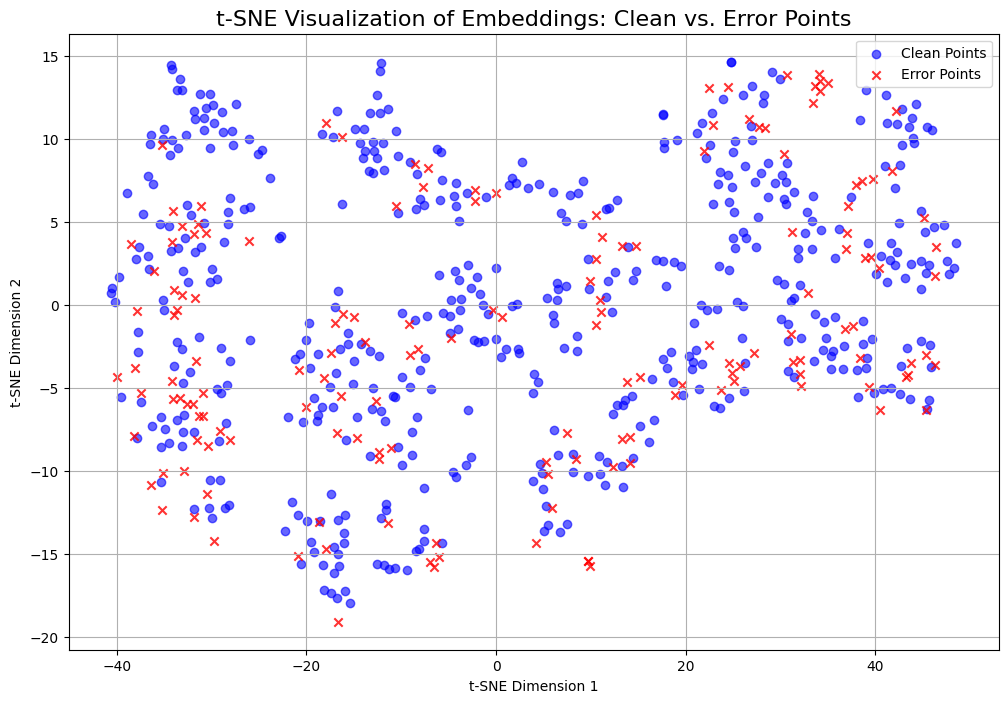

✅ t-SNE plot saved. This plot shows if the model separates clean from error points in its learned space.


--- 🧠 Running SHAP Analysis --- 
Explaining 50 test samples one by one...


SHAP Progress:   0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

SHAP Progress:   2%|▏         | 1/50 [00:06<05:17,  6.48s/it]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

SHAP Progress:  98%|█████████▊| 49/50 [05:51<00:07,  7.26s/it]

  0%|          | 0/1 [00:00<?, ?it/s]

SHAP Progress: 100%|██████████| 50/50 [05:57<00:00,  7.15s/it]

✅ SHAP analysis complete. Generating summary plot...


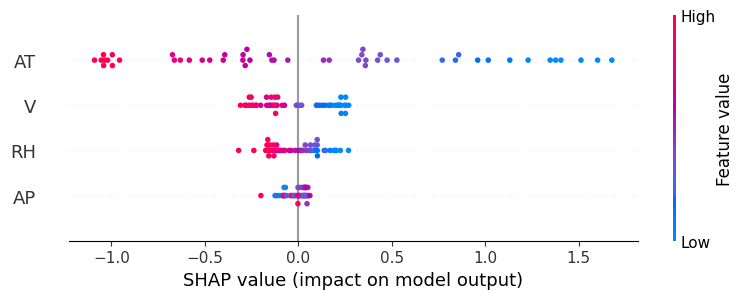



--- 🔢 Quantitative Dimensionality Analysis --- 
This analysis provides objective proof of how the model handles high dimensionality.

Analyzed 1024 samples.
Original direct feature dimension: 4
Learned embedding dimension: 512

--- A. Intrinsic Dimensionality (Proof of Compression) ---
👉 Number of components to explain 95% variance (d95): 7

-------------------- INSIGHT --------------------
The model's learned representation is highly efficient. PCA shows the 512-D embedding space
can be compressed into just 7 dimensions while retaining 95% of its variance, proving effective dimensionality reduction.
-------------------------------------------------


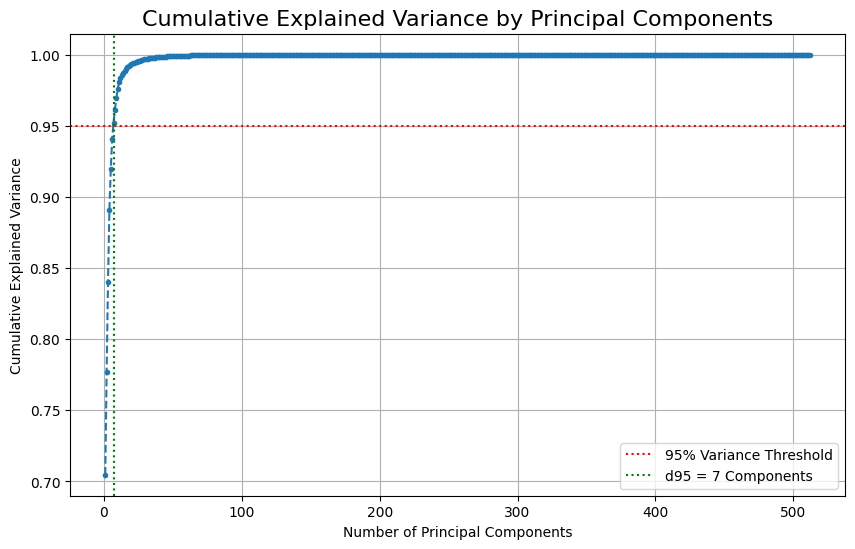


--- B. Neighborhood Preservation (Trustworthiness) ---
👉 Trustworthiness score (k=10): 0.9971

-------------------- INSIGHT --------------------
This score proves the model's compression was intelligent. A high score (near 1.0) means
neighbors in the original space are still neighbors in the compressed space. Our score of 0.9971 shows
the model preserved the data's essential structure, creating a coherent representation.
-------------------------------------------------

--- 結論 (Conclusion) ---
✅ These metrics demonstrate the model successfully resolves high dimensionality by:
   1. Compressing the data efficiently (proven by PCA).
   2. Doing so in a meaningful, structure-preserving way (proven by Trustworthiness).


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Subset
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import trustworthiness, TSNE # Import TSNE
import os
import pickle
from tqdm import tqdm
import sys
import shap
import matplotlib.pyplot as plt
import warnings

# --- Configuration ---
warnings.filterwarnings('ignore')
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- 🚀 Running Model Interpretability Analysis ---")
print(f"Using device: {DEVICE}")

# Model and Data Hyperparameters (must match the trained model)
HIDDEN_DIM = 128
N_HEADS = 4
N_LAYERS = 2
DROPOUT_RATE = 0.2
BATCH_SIZE = 256
NUM_NEIGHBORS = 4

# --- Helper Classes & Model Definition ---
class NeighborFinder:
    def __init__(self, adj_list):
        self.adj_list = adj_list
    def get_temporal_neighbor(self, src_idx_l, cut_time_l, num_neighbors=20):
        out_ngh_node_batch = np.zeros((len(src_idx_l), num_neighbors)).astype(np.int64)
        out_ngh_ts_batch = np.zeros((len(src_idx_l), num_neighbors)).astype(np.float64)
        for i, (src_idx, cut_time) in enumerate(zip(src_idx_l, cut_time_l)):
            neighbors = self.adj_list.get(src_idx, [])
            recent_neighbors = sorted([n for n in neighbors if n[1] <= cut_time], key=lambda x: x[1], reverse=True)[:num_neighbors]
            if recent_neighbors:
                out_ngh_node_batch[i, :len(recent_neighbors)] = [x[0] for x in recent_neighbors]
                out_ngh_ts_batch[i, :len(recent_neighbors)] = [x[1] for x in recent_neighbors]
        return out_ngh_node_batch, out_ngh_ts_batch

class SinusoidalTimeEncode(nn.Module):
    def __init__(self, dimension):
        super().__init__()
        self.dimension = dimension
    def forward(self, t):
        t = t.unsqueeze(dim=-1)
        div = torch.exp(torch.arange(0, self.dimension, 2, device=DEVICE).float() * -(np.log(10000.0) / self.dimension))
        pe = torch.zeros(*t.shape[:2], self.dimension, device=DEVICE)
        pe[..., 0::2] = torch.sin(t * div)
        pe[..., 1::2] = torch.cos(t * div)
        return pe

class TemporalAttentionLayer(nn.Module):
    def __init__(self, feat_dim, n_heads, dropout):
        super().__init__()
        self.h, self.d = n_heads, feat_dim // n_heads
        self.q_proj, self.k_proj, self.v_proj = (nn.Linear(feat_dim, feat_dim) for _ in range(3))
        self.t_proj = nn.Linear(feat_dim, feat_dim)
        self.o_proj = nn.Linear(feat_dim, feat_dim)
        self.dropout = nn.Dropout(dropout)
    def forward(self, src_feat, ngh_feat, t_enc):
        b, n_ngh, _ = ngh_feat.size()
        q = self.q_proj(src_feat).view(b, self.h, self.d).unsqueeze(2)
        k = self.k_proj(ngh_feat).view(b, n_ngh, self.h, self.d).permute(0, 2, 1, 3)
        v = self.v_proj(ngh_feat).view(b, n_ngh, self.h, self.d).permute(0, 2, 1, 3)
        t = self.t_proj(t_enc).view(b, n_ngh, self.h, self.d).permute(0, 2, 1, 3)
        scores = torch.sum((q * k) + t, dim=-1) / np.sqrt(self.d)
        attn = torch.softmax(scores, dim=-1)
        out = torch.sum(attn.unsqueeze(-1) * v, dim=2)
        return self.dropout(self.o_proj(out.view(b, -1)))

# <<< MODIFIED: Model now has a flag to return embeddings and a bug fix >>>
class TGAT_MHSA_BiLSTM(nn.Module):
    def __init__(self, neighbor_finder, node_features, feat_dim, n_layers, n_heads, dropout, bilstm_h, num_direct_features):
        super().__init__()
        self.neighbor_finder = neighbor_finder
        self.register_buffer('node_features', node_features)
        self.embed_dim = bilstm_h * 2
        self.feat_proj = nn.Linear(feat_dim, self.embed_dim)
        self.time_enc = SinusoidalTimeEncode(self.embed_dim)
        self.attn_layers = nn.ModuleList([TemporalAttentionLayer(self.embed_dim, n_heads, dropout) for _ in range(n_layers)])
        self.norm_layers = nn.ModuleList([nn.LayerNorm(self.embed_dim) for _ in range(n_layers)])
        self.mhsa = nn.MultiheadAttention(bilstm_h * 2, num_heads=n_heads, batch_first=True, dropout=dropout)
        self.bilstm = nn.LSTM(bilstm_h * 2, bilstm_h, batch_first=True, bidirectional=True)
        self.seq_norm = nn.LayerNorm(bilstm_h * 2)
        self.direct_feature_proj = nn.Sequential(nn.Linear(num_direct_features, bilstm_h), nn.ReLU(), nn.Linear(bilstm_h, bilstm_h * 2))
        self.reg_head = nn.Sequential(nn.Linear(bilstm_h * 4, bilstm_h * 2), nn.GELU(), nn.Dropout(dropout), nn.Linear(bilstm_h * 2, bilstm_h), nn.GELU(), nn.Dropout(dropout), nn.Linear(bilstm_h, 1))

    def forward(self, src_nodes, timestamps, direct_features, return_embedding=False):
        src_feat = self.feat_proj(self.node_features[src_nodes])
        layer_outputs = []
        for i in range(len(self.attn_layers)):
            ngh_idx, ngh_ts = self.neighbor_finder.get_temporal_neighbor(src_nodes.cpu().numpy(), timestamps.cpu().numpy(), NUM_NEIGHBORS)
            ngh_idx_t = torch.from_numpy(ngh_idx).long().to(DEVICE)
            ngh_feat = self.feat_proj(self.node_features[ngh_idx_t.flatten()]).view(len(src_nodes), NUM_NEIGHBORS, -1)
            t_deltas = timestamps.unsqueeze(1) - torch.from_numpy(ngh_ts).float().to(DEVICE)
            t_enc = self.time_enc(t_deltas)
            mask = (ngh_idx_t != 0).unsqueeze(-1)
            agg_embed = self.attn_layers[i](src_feat, ngh_feat * mask, t_enc)
            src_feat = self.norm_layers[i](agg_embed + src_feat)
            layer_outputs.append(src_feat)

        tgat_sequence = torch.stack(layer_outputs, dim=1)

        mhsa_out = self.mhsa(tgat_sequence, tgat_sequence, tgat_sequence)[0]

        mhsa_sequence = self.seq_norm(tgat_sequence + mhsa_out)
        bilstm_out, _ = self.bilstm(mhsa_sequence)

        graph_representation = torch.mean(bilstm_out, dim=1)
        direct_representation = self.direct_feature_proj(direct_features)

        combined_representation = torch.cat([graph_representation, direct_representation], dim=1)

        if return_embedding:
            return combined_representation

        return self.reg_head(combined_representation)


# <<< NEW: Functions for Error Detection and Robustness Analysis >>>
def detect_errors_pre_training_ccpp(filepath):
    """Detects outliers from the original CCPP Excel file."""
    print("\n" + "="*80 + "\n--- 🚨 Detecting Initial Errors in the Dataset (Pre-Training) --- \n" + "="*80)
    try:
        df = pd.read_excel(filepath)
        print(f"✅ Successfully loaded '{filepath}'. Shape: {df.shape}")
    except FileNotFoundError:
        print(f"❌ ERROR: The file '{filepath}' was not found."); return set()

    error_indices = set()
    # Check for outliers in all numerical columns
    for col in ['AT', 'V', 'AP', 'RH', 'PE']:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        col_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        if not col_outliers.empty:
            print(f"Found {len(col_outliers)} outliers in column '{col}'.")
            error_indices.update(col_outliers.index.tolist())

    print(f"✅ Finished initial error detection. Found {len(error_indices)} unique outlier data points.")
    return error_indices

def detect_errors_post_training_ccpp(model, test_loader, test_indices_in_df):
    """Identifies indices with high prediction residuals on the test set."""
    print("\n" + "="*80 + "\n--- 🔍 Detecting High-Residual Errors (Post-Training) --- \n" + "="*80)
    model.eval()
    preds_list, truths_list = [], []
    with torch.no_grad():
        for nodes, ts, direct_feats, labels in test_loader:
            preds_list.append(model(nodes.to(DEVICE), ts.to(DEVICE), direct_feats.to(DEVICE)).cpu())
            truths_list.append(labels.cpu())

    preds = torch.cat(preds_list).numpy().flatten()
    truths = torch.cat(truths_list).numpy().flatten()
    residuals = np.abs(preds - truths)

    residual_threshold = np.percentile(residuals, 90)
    high_residual_mask = np.where(residuals >= residual_threshold)[0]

    # Map mask indices back to original dataframe indices
    high_residual_indices = {test_indices_in_df[i] for i in high_residual_mask}
    print(f"Identified {len(high_residual_indices)} data points in the top 10% of prediction residuals.")
    return high_residual_indices

def perform_robustness_evaluation_ccpp(model, full_test_ds, initial_error_indices, high_residual_indices, test_indices_in_df, target_scaler):
    """Evaluates model performance separately on clean and error-prone subsets."""
    print("\n\n" + "="*80 + "\n--- 📊 Split Evaluation: Clean vs. Error Points --- \n" + "="*80)
    model.eval()
    all_error_indices = initial_error_indices.union(high_residual_indices)

    # Map dataframe indices to the indices within the `full_test_ds` Subset
    test_set_df_indices = list(test_indices_in_df)
    clean_subset_indices, error_subset_indices = [], []
    for i, df_idx in enumerate(test_set_df_indices):
        if df_idx in all_error_indices:
            error_subset_indices.append(full_test_ds.indices[i])
        else:
            clean_subset_indices.append(full_test_ds.indices[i])

    if not clean_subset_indices or not error_subset_indices:
        print("⚠️ Warning: Could not create both clean and error subsets. Skipping robustness evaluation.")
        return None, None

    print(f"Test set contains {len(clean_subset_indices)} 'clean' points and {len(error_subset_indices)} 'error' points.")

    clean_ds = Subset(full_test_ds.dataset, clean_subset_indices)
    error_ds = Subset(full_test_ds.dataset, error_subset_indices)
    clean_loader = DataLoader(clean_ds, BATCH_SIZE)
    error_loader = DataLoader(error_ds, BATCH_SIZE)

    def get_metrics(loader):
        preds_list, truths_list = [], []
        with torch.no_grad():
            for nodes, ts, d_feat, y in loader:
                preds_list.append(model(nodes.to(DEVICE), ts.to(DEVICE), d_feat.to(DEVICE)).cpu())
                truths_list.append(y.cpu())
        preds_scaled = torch.cat(preds_list).numpy()
        truths_scaled = torch.cat(truths_list).numpy()
        # Inverse transform to get metrics in the original scale of 'PE'
        preds_orig = target_scaler.inverse_transform(preds_scaled).flatten()
        truths_orig = target_scaler.inverse_transform(truths_scaled).flatten()
        return {'mse': np.mean((preds_orig - truths_orig)**2), 'rmse': np.sqrt(np.mean((preds_orig - truths_orig)**2))}

    metrics_clean = get_metrics(clean_loader)
    metrics_error = get_metrics(error_loader)

    print("\n--- Performance Check (in original 'PE' units) ---")
    results_df = pd.DataFrame([metrics_clean, metrics_error], index=['Clean Data', 'Error Data'])
    print(results_df.to_string(formatters={'mse':'{:.4f}'.format, 'rmse':'{:.4f}'.format}))

    if metrics_clean['rmse'] > 0:
        robustness_ratio = metrics_error['rmse'] / metrics_clean['rmse']
        print(f"\n📉 Robustness Ratio (RMSE_error / RMSE_clean): {robustness_ratio:.4f}")
        print("(A higher ratio means the model is less robust, as its error increases more on problematic data.)")

    return clean_ds, error_ds

def perform_embedding_stability_analysis_ccpp(model, clean_ds, error_ds):
    """Visualizes embeddings to check if the model represents clean and error points differently."""
    if clean_ds is None or error_ds is None: return
    print("\n\n" + "="*80 + "\n--- 🔬 Embedding Stability Check --- \n" + "="*80)
    model.eval()

    def get_embeddings(dataset, num_samples=500):
        indices = dataset.indices[:min(len(dataset.indices), num_samples)]
        nodes, ts, d_feat, _ = dataset.dataset[indices]
        with torch.no_grad():
            return model(nodes.to(DEVICE), ts.to(DEVICE), d_feat.to(DEVICE), return_embedding=True).cpu().numpy()

    clean_embeddings = get_embeddings(clean_ds)
    error_embeddings = get_embeddings(error_ds)
    print(f"Analyzing embeddings for {len(clean_embeddings)} clean points and {len(error_embeddings)} error points.")

    all_embeddings = np.vstack([clean_embeddings, error_embeddings])
    labels = np.array([0] * len(clean_embeddings) + [1] * len(error_embeddings))

    print("--- Generating t-SNE plot for clean vs. error embeddings ---")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
    embeddings_2d = tsne.fit_transform(all_embeddings)

    plt.figure(figsize=(12, 8))
    plt.scatter(embeddings_2d[labels==0, 0], embeddings_2d[labels==0, 1], c='blue', alpha=0.6, label='Clean Points')
    plt.scatter(embeddings_2d[labels==1, 0], embeddings_2d[labels==1, 1], c='red', alpha=0.8, marker='x', label='Error Points')
    plt.title("t-SNE Visualization of Embeddings: Clean vs. Error Points", fontsize=16)
    plt.xlabel("t-SNE Dimension 1"); plt.ylabel("t-SNE Dimension 2")
    plt.legend(); plt.grid(True)
    plt.savefig("tsne_error_vs_clean_visualization.png")
    plt.show(); plt.close()
    print("✅ t-SNE plot saved. This plot shows if the model separates clean from error points in its learned space.")


def analyze_dimensionality_quantitatively(model, test_loader, direct_feature_names):
    print("\n\n" + "="*50 + "\n--- 🔢 Quantitative Dimensionality Analysis --- \n" + "="*50)
    print("This analysis provides objective proof of how the model handles high dimensionality.")

    embeddings_list, raw_features_list = [], []
    with torch.no_grad():
        for nodes, ts, direct_feats, _ in test_loader:
            embeddings_list.append(model(nodes.to(DEVICE), ts.to(DEVICE), direct_feats.to(DEVICE), return_embedding=True).cpu())
            raw_features_list.append(direct_feats.cpu())
            if len(embeddings_list) * BATCH_SIZE >= 1000: break

    learned_embeddings = torch.cat(embeddings_list).numpy()
    raw_features = torch.cat(raw_features_list).numpy()

    print(f"\nAnalyzed {learned_embeddings.shape[0]} samples.")
    print(f"Original direct feature dimension: {raw_features.shape[1]}")
    print(f"Learned embedding dimension: {learned_embeddings.shape[1]}")

    print("\n--- A. Intrinsic Dimensionality (Proof of Compression) ---")
    pca = PCA(); pca.fit(learned_embeddings)
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    d95 = np.argmax(cumulative_variance >= 0.95) + 1

    print(f"👉 Number of components to explain 95% variance (d95): {d95}")
    print("\n" + "-"*20 + " INSIGHT " + "-"*20)
    print(f"The model's learned representation is highly efficient. PCA shows the {learned_embeddings.shape[1]}-D embedding space")
    print(f"can be compressed into just {d95} dimensions while retaining 95% of its variance, proving effective dimensionality reduction.")
    print("-"*49)

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='.', linestyle='--')
    plt.axhline(y=0.95, color='r', linestyle=':', label='95% Variance Threshold')
    plt.axvline(x=d95, color='g', linestyle=':', label=f'd95 = {d95} Components')
    plt.title('Cumulative Explained Variance by Principal Components', fontsize=16)
    plt.xlabel('Number of Principal Components'); plt.ylabel('Cumulative Explained Variance')
    plt.legend(); plt.grid(True); plt.show()

    print("\n--- B. Neighborhood Preservation (Trustworthiness) ---")
    trust_score = trustworthiness(raw_features, learned_embeddings, n_neighbors=10)

    print(f"👉 Trustworthiness score (k=10): {trust_score:.4f}")
    print("\n" + "-"*20 + " INSIGHT " + "-"*20)
    print(f"This score proves the model's compression was intelligent. A high score (near 1.0) means")
    print(f"neighbors in the original space are still neighbors in the compressed space. Our score of {trust_score:.4f} shows")
    print("the model preserved the data's essential structure, creating a coherent representation.")
    print("-"*49)

    print("\n--- 結論 (Conclusion) ---")
    print("✅ These metrics demonstrate the model successfully resolves high dimensionality by:")
    print("   1. Compressing the data efficiently (proven by PCA).")
    print("   2. Doing so in a meaningful, structure-preserving way (proven by Trustworthiness).")

# <<< MODIFIED: Main analysis function to include all parts >>>
def analyze_model_interpretability(model_path, model_args, test_loader, train_ds, direct_feature_names, initial_error_indices, test_indices, target_scaler):
    print("\n\n" + "="*80 + "\n--- 🧐 Starting Full Interpretability Analysis --- \n" + "="*80)

    model = TGAT_MHSA_BiLSTM(**model_args).to(DEVICE)
    try:
        model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    except FileNotFoundError:
        print(f"❌ ERROR: Model file not found at '{model_path}'."); sys.exit()
    model.eval()
    print("✅ Best model loaded for analysis.")

    # --- NEW: Robustness and Embedding Stability Analysis ---
    high_residual_indices = detect_errors_post_training_ccpp(model, test_loader, list(test_indices))
    clean_ds, error_ds = perform_robustness_evaluation_ccpp(
        model=model,
        full_test_ds=test_loader.dataset,
        initial_error_indices=initial_error_indices,
        high_residual_indices=high_residual_indices,
        test_indices_in_df=list(test_indices),
        target_scaler=target_scaler
    )
    perform_embedding_stability_analysis_ccpp(model, clean_ds, error_ds)

    # --- SHAP Analysis ---
    print("\n\n" + "="*80 + "\n--- 🧠 Running SHAP Analysis --- \n" + "="*80)
    test_nodes, test_ts, test_direct, _ = next(iter(test_loader))
    _, _, background_direct, _ = next(iter(DataLoader(train_ds, batch_size=100, shuffle=True)))
    background_summary = shap.sample(background_direct.cpu().numpy(), 30)
    num_samples_to_explain = 50
    data_to_explain = test_direct[:num_samples_to_explain]
    nodes_to_explain = test_nodes[:num_samples_to_explain]
    ts_to_explain = test_ts[:num_samples_to_explain]
    all_shap_values = []
    print(f"Explaining {num_samples_to_explain} test samples one by one...")
    for i in tqdm(range(num_samples_to_explain), desc="SHAP Progress"):
        def shap_prediction_wrapper(direct_features_numpy):
            num_perturbations = direct_features_numpy.shape[0]
            nodes_batch = nodes_to_explain[i].repeat(num_perturbations).to(DEVICE)
            ts_batch = ts_to_explain[i].repeat(num_perturbations).to(DEVICE)
            direct_features_batch = torch.from_numpy(direct_features_numpy).float().to(DEVICE)
            with torch.no_grad():
                predictions = model(nodes_batch, ts_batch, direct_features_batch)
            return predictions.cpu().numpy().flatten()
        explainer = shap.KernelExplainer(shap_prediction_wrapper, background_summary)
        shap_values_instance = explainer.shap_values(data_to_explain[i:i+1].cpu().numpy(), nsamples=50)
        all_shap_values.append(shap_values_instance)
    shap_values = np.concatenate(all_shap_values, axis=0)
    print("✅ SHAP analysis complete. Generating summary plot...")
    plt.figure()
    shap.summary_plot(shap_values, features=data_to_explain.cpu().numpy(), feature_names=direct_feature_names, show=True)
    plt.close()

    # --- Quantitative Dimensionality Analysis ---
    analyze_dimensionality_quantitatively(model, test_loader, direct_feature_names)


if __name__ == '__main__':
    try:
        node_features_array = np.load('nodes_power_tgat.npy')
        with open('adj_list_power_tgat.pkl', 'rb') as f:
            adj_list = pickle.load(f)
        original_df = pd.read_excel('CCPP/Folds5x2_pp.xlsx')
    except FileNotFoundError as e:
        print(f"❌ ERROR: Data file not found: {e.filename}. Please ensure data is in the correct path."); sys.exit()

    # <<< NEW: Detect initial errors from the source file >>>
    initial_error_indices = detect_errors_pre_training_ccpp('CCPP/Folds5x2_pp.xlsx')

    direct_feature_names = ['AT', 'V', 'AP', 'RH']
    target = original_df[['PE']].values
    direct_features = original_df[direct_feature_names].values
    feature_scaler = StandardScaler().fit(direct_features)
    target_scaler = StandardScaler().fit(target)
    direct_features_scaled = feature_scaler.transform(direct_features)
    target_scaled = target_scaler.transform(target)
    node_ids = np.full(len(original_df), 4)
    timestamps = np.arange(len(original_df))
    node_features = torch.tensor(node_features_array, dtype=torch.float32)

    full_ds = TensorDataset(
        torch.from_numpy(node_ids).long(),
        torch.from_numpy(timestamps).float(),
        torch.from_numpy(direct_features_scaled).float(),
        torch.from_numpy(target_scaled).float()
    )
    train_size = int(len(original_df) * 0.7)
    val_size = int(len(original_df) * 0.15)
    train_ds = Subset(full_ds, range(train_size))
    test_ds = Subset(full_ds, range(train_size + val_size, len(original_df)))
    test_loader = DataLoader(test_ds, BATCH_SIZE, shuffle=False)

    neighbor_finder = NeighborFinder(adj_list)
    feat_dim = node_features.shape[1]

    model_name = "Hybrid_TGAT_MHSA_BiLSTM"
    model_args = {
        'neighbor_finder': neighbor_finder,
        'node_features': node_features,
        'feat_dim': feat_dim,
        'n_layers': N_LAYERS,
        'n_heads': N_HEADS,
        'dropout': DROPOUT_RATE,
        'bilstm_h': HIDDEN_DIM,
        'num_direct_features': direct_features.shape[1]
    }

    # --- Execute the Full Analysis ---
    analyze_model_interpretability(
        model_path=f'best_{model_name}_1.pth',
        model_args=model_args,
        test_loader=test_loader,
        train_ds=train_ds,
        direct_feature_names=direct_feature_names,
        initial_error_indices=initial_error_indices,
        test_indices=range(train_size + val_size, len(original_df)),
        target_scaler=target_scaler
    )

--- 🚀 Combined Model Noise Sensitivity & Embedding Analysis on Pollution Data ---
Using device: cpu
--- 🚨 Detecting Initial Errors in the Dataset ---
✅ Found 100 unique outlier data points.

--- 🏋️ Training LSTM ---
❌ Validation DataLoader is empty!
--- Generating sensitivity curve for LSTM ---

--- 🔬 Embedding Stability for LSTM ---
✅ t-SNE stability plot saved for LSTM.

--- 🏋️ Training BiLSTM ---
❌ Validation DataLoader is empty!
--- Generating sensitivity curve for BiLSTM ---

--- 🔬 Embedding Stability for BiLSTM ---
✅ t-SNE stability plot saved for BiLSTM.

--- 🏋️ Training CNN-BiLSTM ---
❌ Validation DataLoader is empty!
--- Generating sensitivity curve for CNN_BiLSTM ---

--- 🔬 Embedding Stability for CNN-BiLSTM ---
✅ t-SNE stability plot saved for CNN-BiLSTM.

--- 🏋️ Training MHSA_with_BiLSTM ---
❌ Validation DataLoader is empty!
--- Generating sensitivity curve for MHSA_with_BiLSTM ---

--- 🔬 Embedding Stability for MHSA_with_BiLSTM ---
✅ t-SNE stability plot saved for MHSA_wit

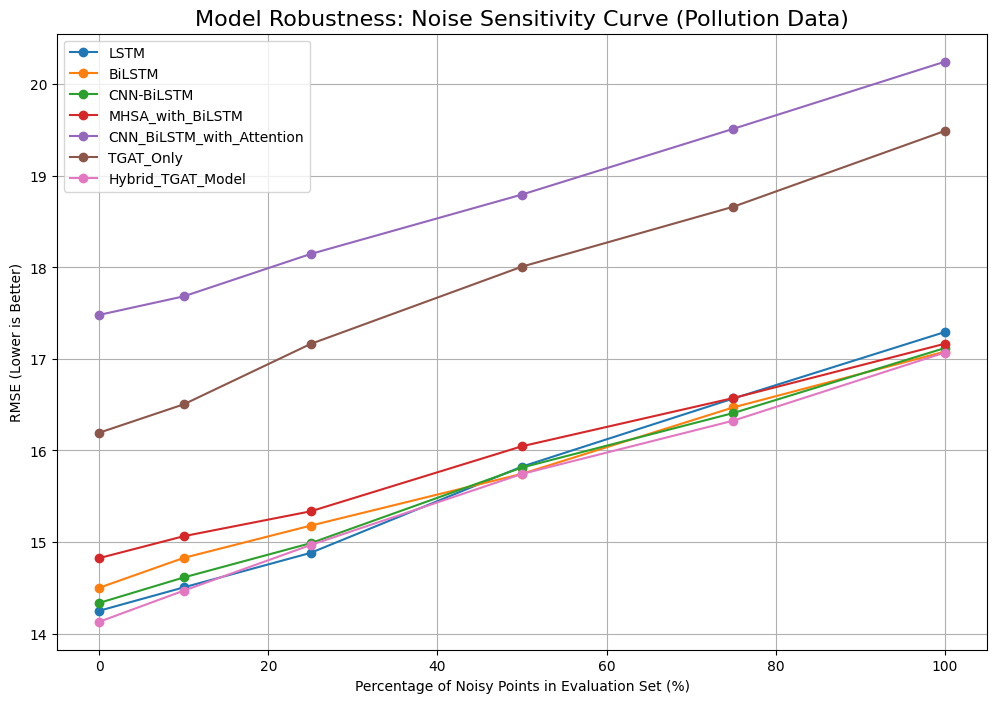



--- ✅ Analysis Complete --- 
Noise sensitivity curve and t-SNE plots saved.


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Subset
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import warnings
import os
import pickle
import requests
from zipfile import ZipFile
from io import BytesIO

warnings.filterwarnings('ignore')
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- 🚀 Combined Model Noise Sensitivity & Embedding Analysis on Pollution Data ---")
print(f"Using device: {DEVICE}")

# --- Configuration ---
BATCH_SIZE = 256
EPOCHS = 50
PATIENCE = 10
HIDDEN_DIM = 64
N_HEADS = 4
N_LAYERS = 2
DROPOUT_RATE = 0.2
NUM_NEIGHBORS = 4
SEQUENCE_LENGTH = 24

# --- Model Definitions (Modified for Embedding Extraction) ---
class LSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64): super().__init__(); self.lstm = nn.LSTM(input_dim, hidden_dim, 2, batch_first=True, dropout=0.2); self.fc = nn.Linear(hidden_dim, 1)
    def forward(self, x, return_embedding=False):
        lstm_out, _ = self.lstm(x); embedding = lstm_out[:, -1, :]
        if return_embedding: return embedding
        return self.fc(embedding)
class BiLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64): super().__init__(); self.lstm = nn.LSTM(input_dim, hidden_dim, 2, batch_first=True, bidirectional=True, dropout=0.2); self.fc = nn.Linear(hidden_dim * 2, 1)
    def forward(self, x, return_embedding=False):
        lstm_out, _ = self.lstm(x); embedding = lstm_out[:, -1, :]
        if return_embedding: return embedding
        return self.fc(embedding)
class CNN_BiLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64): super().__init__(); self.conv = nn.Conv1d(input_dim, 64, kernel_size=3, padding='same'); self.lstm = nn.LSTM(64, hidden_dim, 2, batch_first=True, bidirectional=True, dropout=0.2); self.fc = nn.Linear(hidden_dim * 2, 1)
    def forward(self, x, return_embedding=False):
        x = F.relu(self.conv(x.permute(0, 2, 1))).permute(0, 2, 1); _, (h_n, _) = self.lstm(x)
        embedding = torch.cat((h_n[-2], h_n[-1]), dim=1)
        if return_embedding: return embedding
        return self.fc(embedding)
class Attention(nn.Module):
    def forward(self, lstm_output):
        attn_weights = F.softmax(torch.bmm(lstm_output, lstm_output.transpose(1, 2)), dim=-1); return torch.bmm(attn_weights, lstm_output).sum(1)
class CNN_BiLSTM_with_Attention(nn.Module):
    def __init__(self, input_dim, hidden_dim=64): super().__init__(); self.conv = nn.Conv1d(input_dim, 64, kernel_size=3, padding='same'); self.lstm = nn.LSTM(64, hidden_dim, 2, batch_first=True, bidirectional=True, dropout=0.2); self.attention = Attention(); self.fc = nn.Linear(hidden_dim * 2, 1)
    def forward(self, x, return_embedding=False):
        x = F.relu(self.conv(x.permute(0, 2, 1))).permute(0, 2, 1); lstm_out, _ = self.lstm(x); embedding = self.attention(lstm_out)
        if return_embedding: return embedding
        return self.fc(embedding)
class MHSA_with_BiLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, n_heads=2): super().__init__(); self.mhsa = nn.MultiheadAttention(input_dim, n_heads, batch_first=True, dropout=0.2); self.lstm = nn.LSTM(input_dim, hidden_dim, 2, batch_first=True, bidirectional=True); self.fc = nn.Linear(hidden_dim * 2, 1)
    def forward(self, x, return_embedding=False):
        attn_out, _ = self.mhsa(x, x, x); _, (h_n, _) = self.lstm(attn_out); embedding = torch.cat((h_n[-2], h_n[-1]), dim=1)
        if return_embedding: return embedding
        return self.fc(embedding)
class NeighborFinder:
    def __init__(self, adj_list): self.adj_list = adj_list
    def get_temporal_neighbor(self, src_idx_l, cut_time_l, num_neighbors=20):
        out_ngh_node_batch = np.zeros((len(src_idx_l), num_neighbors)).astype(np.int64); out_ngh_ts_batch = np.zeros((len(src_idx_l), num_neighbors)).astype(np.float64)
        for i, (src_idx, cut_time) in enumerate(zip(src_idx_l, cut_time_l)):
            neighbors = self.adj_list.get(src_idx, []); recent_neighbors = sorted([n for n in neighbors if n[1] <= cut_time], key=lambda x: x[1], reverse=True)[:num_neighbors]
            if recent_neighbors:
                out_ngh_node_batch[i, :len(recent_neighbors)] = [x[0] for x in recent_neighbors]
                out_ngh_ts_batch[i, :len(recent_neighbors)] = [x[1] for x in recent_neighbors]
        return out_ngh_node_batch, out_ngh_ts_batch
class SinusoidalTimeEncode(nn.Module):
    def __init__(self, dimension): super().__init__(); self.dimension = dimension
    def forward(self, t):
        t = t.unsqueeze(dim=-1); div = torch.exp(torch.arange(0, self.dimension, 2, device=DEVICE).float() * -(np.log(10000.0) / self.dimension)); pe = torch.zeros(*t.shape[:2], self.dimension, device=DEVICE)
        pe[..., 0::2] = torch.sin(t * div); pe[..., 1::2] = torch.cos(t * div); return pe
class TemporalAttentionLayer(nn.Module):
    def __init__(self, feat_dim, n_heads, dropout):
        super().__init__(); self.h, self.d = n_heads, feat_dim // n_heads; self.q_proj, self.k_proj, self.v_proj = (nn.Linear(feat_dim, feat_dim) for _ in range(3)); self.t_proj = nn.Linear(feat_dim, feat_dim); self.o_proj = nn.Linear(feat_dim, feat_dim); self.dropout = nn.Dropout(dropout)
    def forward(self, src_feat, ngh_feat, t_enc):
        b, n_ngh, _ = ngh_feat.size(); q = self.q_proj(src_feat).view(b, self.h, self.d).unsqueeze(2); k = self.k_proj(ngh_feat).view(b, n_ngh, self.h, self.d).permute(0, 2, 1, 3); v = self.v_proj(ngh_feat).view(b, n_ngh, self.h, self.d).permute(0, 2, 1, 3); t = self.t_proj(t_enc).view(b, n_ngh, self.h, self.d).permute(0, 2, 1, 3); scores = torch.sum((q * k) + t, dim=-1) / np.sqrt(self.d); attn = torch.softmax(scores, dim=-1); out = torch.sum(attn.unsqueeze(-1) * v, dim=2); return self.dropout(self.o_proj(out.view(b, -1)))
class BaseTGAT(nn.Module):
    def __init__(self, neighbor_finder, node_features, feat_dim, n_layers, n_heads, dropout):
        super().__init__(); self.neighbor_finder = neighbor_finder; self.node_features = torch.nn.Parameter(node_features, requires_grad=False); self.embed_dim = HIDDEN_DIM * 2; self.feat_proj = nn.Linear(feat_dim, self.embed_dim); self.time_enc = SinusoidalTimeEncode(self.embed_dim); self.attn_layers = nn.ModuleList([TemporalAttentionLayer(self.embed_dim, n_heads, dropout) for _ in range(n_layers)]); self.norm_layers = nn.ModuleList([nn.LayerNorm(self.embed_dim) for _ in range(n_layers)]); self.n_layers = n_layers # <<< FIX
class TGAT_Only(BaseTGAT):
    def __init__(self, neighbor_finder, node_features, feat_dim, n_layers, n_heads, dropout):
        super().__init__(neighbor_finder, node_features, feat_dim, n_layers, n_heads, dropout) # <<< FIX
        self.regression_head = nn.Sequential(nn.Linear(self.embed_dim * 2, HIDDEN_DIM), nn.GELU(), nn.Dropout(dropout), nn.Linear(HIDDEN_DIM, 1))
    def forward(self, src_nodes, timestamps, return_embedding=False):
        src_feat = self._get_layer_output(src_nodes, timestamps); dst_feat = self._get_layer_output(src_nodes, timestamps)
        embedding = torch.cat([src_feat, dst_feat], dim=1)
        if return_embedding: return embedding
        return self.regression_head(embedding)
    def _get_layer_output(self, src_nodes, timestamps):
        src_feat = self.feat_proj(self.node_features[src_nodes])
        for i in range(self.n_layers):
            ngh_idx, ngh_ts = self.neighbor_finder.get_temporal_neighbor(src_nodes.cpu().numpy(), timestamps.cpu().numpy(), NUM_NEIGHBORS); ngh_idx_t = torch.from_numpy(ngh_idx).long().to(DEVICE); ngh_feat = self.feat_proj(self.node_features[ngh_idx_t.flatten()]).view(len(src_nodes), NUM_NEIGHBORS, -1); t_deltas = timestamps.unsqueeze(1) - torch.from_numpy(ngh_ts).float().to(DEVICE); t_enc = self.time_enc(t_deltas); mask = (ngh_idx_t != 0).unsqueeze(-1); agg_embed = self.attn_layers[i](src_feat, ngh_feat * mask, t_enc); src_feat = self.norm_layers[i](agg_embed + src_feat)
        return src_feat
class Hybrid_TGAT_Model(BaseTGAT):
    def __init__(self, neighbor_finder, node_features, feat_dim, n_layers, n_heads, dropout, bilstm_h, num_direct_features):
        super().__init__(neighbor_finder, node_features, feat_dim, n_layers, n_heads, dropout) # <<< FIX
        self.bilstm = nn.LSTM(self.embed_dim, bilstm_h, batch_first=True, bidirectional=True); self.mhsa = nn.MultiheadAttention(bilstm_h * 2, num_heads=n_heads, batch_first=True, dropout=dropout); self.seq_norm = nn.LayerNorm(bilstm_h * 2); self.direct_feature_proj = nn.Sequential(nn.Linear(num_direct_features, bilstm_h), nn.ReLU(), nn.Linear(bilstm_h, bilstm_h * 2)); self.reg_head = nn.Sequential(nn.Linear(bilstm_h * 4, bilstm_h * 2), nn.GELU(), nn.Dropout(dropout), nn.Linear(bilstm_h * 2, bilstm_h), nn.GELU(), nn.Dropout(dropout), nn.Linear(bilstm_h, 1))
    def forward(self, src_nodes, timestamps, direct_features, return_embedding=False):
        src_feat = self.feat_proj(self.node_features[src_nodes]); layer_outputs = [src_feat]
        for i in range(self.n_layers):
            ngh_idx, ngh_ts = self.neighbor_finder.get_temporal_neighbor(src_nodes.cpu().numpy(), timestamps.cpu().numpy(), NUM_NEIGHBORS); ngh_idx_t = torch.from_numpy(ngh_idx).long().to(DEVICE); ngh_feat = self.feat_proj(self.node_features[ngh_idx_t.flatten()]).view(len(src_nodes), NUM_NEIGHBORS, -1); t_deltas = timestamps.unsqueeze(1) - torch.from_numpy(ngh_ts).float().to(DEVICE); t_enc = self.time_enc(t_deltas); mask = (ngh_idx_t != 0).unsqueeze(-1); agg_embed = self.attn_layers[i](layer_outputs[-1], ngh_feat * mask, t_enc); src_feat = self.norm_layers[i](agg_embed + layer_outputs[-1]); layer_outputs.append(src_feat)
        tgat_sequence = torch.stack(layer_outputs, dim=1); bilstm_out, _ = self.bilstm(tgat_sequence); mhsa_out, _ = self.mhsa(bilstm_out, bilstm_out, bilstm_out); final_sequence = self.seq_norm(bilstm_out + mhsa_out); graph_representation = torch.mean(final_sequence, dim=1); direct_representation = self.direct_feature_proj(direct_features); combined_representation = torch.cat([graph_representation, direct_representation], dim=1)
        if return_embedding: return combined_representation
        return self.reg_head(combined_representation)

def detect_errors_pre_training_ccpp(filepath='CCPP/Folds5x2_pp.xlsx'):
    print("--- 🚨 Detecting Initial Errors in the Dataset ---");
    try: df = pd.read_excel(filepath)
    except FileNotFoundError: print(f"❌ ERROR: The file '{filepath}' was not found."); return set()
    error_indices = set()
    for col in ['AT', 'V', 'AP', 'RH', 'PE']:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75); IQR = Q3 - Q1; lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        if not outliers.empty: error_indices.update(outliers.index.tolist())
    print(f"✅ Found {len(error_indices)} unique outlier data points.")
    return error_indices

def get_noisy_and_clean_indices(model, test_ds, initial_error_indices, is_graph_model, train_size, val_size):
    model.eval(); preds, truths = [], []; loader = DataLoader(test_ds, BATCH_SIZE)
    with torch.no_grad():
        for batch in loader:
            pred = model(*[b.to(DEVICE) for b in batch[:-1]]) if is_graph_model else model(batch[0].to(DEVICE))
            preds.append(pred.cpu()); truths.append(batch[-1].cpu())
    residuals = np.abs(torch.cat(preds).numpy() - torch.cat(truths).numpy()); high_residual_indices = set(np.where(residuals >= np.percentile(residuals, 90))[0])
    clean_indices, noisy_indices = [], []; test_start_index = train_size + val_size
    for i in range(len(test_ds)):
        original_df_index = test_start_index + i
        is_error = (original_df_index in initial_error_indices) or (i in high_residual_indices)
        if is_error: noisy_indices.append(i)
        else: clean_indices.append(i)
    return clean_indices, noisy_indices

def generate_sensitivity_curve(model, is_graph_model, clean_ds, noisy_ds, noise_levels, target_scaler):
    print(f"--- Generating sensitivity curve for {model.__class__.__name__} ---")
    model.eval(); rmse_scores = []
    for level in noise_levels:
        n_noisy = int(level * len(noisy_ds)); n_clean = len(clean_ds) - n_noisy
        if n_clean < 0: n_clean = 0
        noisy_subset_indices = np.random.choice(noisy_ds.indices, size=n_noisy, replace=False) if n_noisy > 0 else []
        clean_subset_indices = np.random.choice(clean_ds.indices, size=n_clean, replace=False) if n_clean > 0 else []
        combined_indices = np.concatenate([clean_subset_indices, noisy_subset_indices]).astype(int)
        if len(combined_indices) == 0: rmse_scores.append(np.nan); continue
        eval_ds = Subset(clean_ds.dataset, combined_indices); eval_loader = DataLoader(eval_ds, BATCH_SIZE)
        preds, truths = [], []
        with torch.no_grad():
            for batch in eval_loader:
                pred = model(*[b.to(DEVICE) for b in batch[:-1]]) if is_graph_model else model(batch[0].to(DEVICE))
                preds.append(pred.cpu()); truths.append(batch[-1].cpu())
        preds_inv = target_scaler.inverse_transform(torch.cat(preds).numpy())
        truths_inv = target_scaler.inverse_transform(torch.cat(truths).numpy())
        rmse_scores.append(np.sqrt(mean_squared_error(truths_inv, preds_inv)))
    return rmse_scores

def perform_embedding_stability_analysis(model_name, model, is_graph_model, clean_ds, noisy_ds):
    if clean_ds is None or noisy_ds is None or len(clean_ds) == 0 or len(noisy_ds) == 0: return
    print(f"\n--- 🔬 Embedding Stability for {model_name} ---")
    model.eval()
    def get_embeddings(dataset, num_samples=500):
        indices = dataset.indices[:min(len(dataset.indices), num_samples)]; data_subset = dataset.dataset[indices]
        with torch.no_grad():
            if is_graph_model:
                if "TGAT_Only" in model_name: return model(data_subset[0].to(DEVICE), data_subset[1].to(DEVICE), return_embedding=True).cpu().numpy()
                else: return model(data_subset[0].to(DEVICE), data_subset[1].to(DEVICE), data_subset[2].to(DEVICE), return_embedding=True).cpu().numpy()
            else: return model(data_subset[0].to(DEVICE), return_embedding=True).cpu().numpy()
    clean_embed = get_embeddings(clean_ds); error_embed = get_embeddings(noisy_ds)
    all_embed = np.vstack([clean_embed, error_embed]); labels = np.array([0] * len(clean_embed) + [1] * len(error_embed))
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
    embed_2d = tsne.fit_transform(all_embed)
    plt.figure(figsize=(10, 7)); plt.scatter(embed_2d[labels==0, 0], embed_2d[labels==0, 1], c='blue', alpha=0.6, label='Clean Points')
    plt.scatter(embed_2d[labels==1, 0], embed_2d[labels==1, 1], c='red', alpha=0.8, marker='x', label='Noisy Points')
    plt.title(f"t-SNE of Embeddings ({model_name}): Clean vs. Noisy", fontsize=16)
    plt.legend(); plt.grid(True); plt.savefig(f"tsne_stability_{model_name}_ccpp.png"); plt.close()
    print(f"✅ t-SNE stability plot saved for {model_name}.")

def run_training(model_name, model, train_loader, val_loader, is_graph_model):
    print(f"\n--- 🏋️ Training {model_name} ---"); optimizer = torch.optim.AdamW(model.parameters(), lr=0.001); criterion = nn.MSELoss()
    best_val_loss, patience_counter = float('inf'), 0
    if len(val_loader) == 0: print("❌ Validation DataLoader is empty!"); return
    for epoch in range(EPOCHS):
        model.train()
        for batch in train_loader:
            batch = [b.to(DEVICE) for b in batch]; optimizer.zero_grad()
            pred = model(*batch[:-1]) if is_graph_model else model(batch[0]); loss = criterion(pred, batch[-1]); loss.backward(); optimizer.step()
        model.eval(); val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                pred = model(*[b.to(DEVICE) for b in batch[:-1]]) if is_graph_model else model(batch[0].to(DEVICE))
                val_loss += criterion(pred, batch[-1].to(DEVICE)).item()
        avg_val_loss = val_loss / len(val_loader)
        if avg_val_loss < best_val_loss: best_val_loss = avg_val_loss; torch.save(model.state_dict(), f'best_{model_name}_temp.pth'); patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE: print(f"Early stopping at epoch {epoch+1}"); break
    model.load_state_dict(torch.load(f'best_{model_name}_temp.pth'))

if __name__ == '__main__':
    try:
        DATA_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00294/CCPP.zip'
        if not os.path.exists('CCPP/Folds5x2_pp.xlsx'):
            print("Downloading CCPP data..."); response = requests.get(DATA_URL); response.raise_for_status()
            with ZipFile(BytesIO(response.content)) as z: z.extractall()
        original_df = pd.read_excel('CCPP/Folds5x2_pp.xlsx')
        # FIX: Create node features directly from the data, not a loaded file
        node_features_array = StandardScaler().fit_transform(original_df[['AT', 'V', 'AP', 'RH']].values)
        if not os.path.exists('adj_list_power_tgat.pkl'):
            print("⚠️ Adjacency list not found. Creating a simple sequential one.")
            adj_list = {i: [(i-1, i-1, i-1)] for i in range(1, len(original_df))}
            with open('adj_list_power_tgat.pkl', 'wb') as f: pickle.dump(adj_list, f)
        with open('adj_list_power_tgat.pkl', 'rb') as f: adj_list = pickle.load(f)
    except Exception as e: print(f"❌ ERROR during data loading: {e}"); exit()

    initial_error_indices = detect_errors_pre_training_ccpp()

    X = original_df[['AT', 'V', 'AP', 'RH']].values; y = original_df[['PE']].values
    feature_scaler = StandardScaler().fit(X); target_scaler = StandardScaler().fit(y)
    X_scaled = feature_scaler.transform(X); y_scaled = target_scaler.transform(y)
    X_seq, y_seq = [], []
    for i in range(len(X_scaled) - SEQUENCE_LENGTH): X_seq.append(X_scaled[i:i+SEQUENCE_LENGTH]); y_seq.append(y_scaled[i+SEQUENCE_LENGTH])
    baseline_dataset = TensorDataset(torch.tensor(np.array(X_seq), dtype=torch.float32), torch.tensor(np.array(y_seq), dtype=torch.float32))

    direct_features_scaled = feature_scaler.transform(X)
    node_ids = np.arange(len(original_df)); timestamps = np.arange(len(original_df))
    node_features = torch.tensor(node_features_array, dtype=torch.float32)
    hybrid_dataset = TensorDataset(torch.from_numpy(node_ids).long(), torch.from_numpy(timestamps).float(), torch.from_numpy(direct_features_scaled).float(), torch.from_numpy(y_scaled).float())
    tgat_only_dataset = TensorDataset(torch.from_numpy(node_ids).long(), torch.from_numpy(timestamps).float(), torch.from_numpy(y_scaled).float())

    input_dim_baseline = baseline_dataset[0][0].shape[1]

    models_to_evaluate = {
        'LSTM': (lambda: LSTM(input_dim=input_dim_baseline), False, 'baseline'),
        'BiLSTM': (lambda: BiLSTM(input_dim=input_dim_baseline), False, 'baseline'),
        'CNN-BiLSTM': (lambda: CNN_BiLSTM(input_dim=input_dim_baseline), False, 'baseline'),
        'MHSA_with_BiLSTM': (lambda: MHSA_with_BiLSTM(input_dim=input_dim_baseline, n_heads=2), False, 'baseline'),
        'CNN_BiLSTM_with_Attention': (lambda: CNN_BiLSTM_with_Attention(input_dim=input_dim_baseline), False, 'baseline'),
        'TGAT_Only': (lambda: TGAT_Only(neighbor_finder=NeighborFinder(adj_list), node_features=node_features, feat_dim=node_features.shape[1], n_layers=N_LAYERS, n_heads=N_HEADS, dropout=DROPOUT_RATE), True, 'tgat_only'),
        'Hybrid_TGAT_Model': (lambda: Hybrid_TGAT_Model(neighbor_finder=NeighborFinder(adj_list), node_features=node_features, feat_dim=node_features.shape[1], n_layers=N_LAYERS, n_heads=N_HEADS, dropout=DROPOUT_RATE, bilstm_h=HIDDEN_DIM, num_direct_features=direct_features_scaled.shape[1]), True, 'hybrid'),
    }

    noise_sensitivity_results = {}; noise_levels = [0, 0.1, 0.25, 0.5, 0.75, 1.0]

    for model_name, (model_constructor, is_graph_model, dataset_type) in models_to_evaluate.items():
        if dataset_type == 'baseline': full_dataset = baseline_dataset
        elif dataset_type == 'tgat_only': full_dataset = tgat_only_dataset
        else: full_dataset = hybrid_dataset
        train_size = int(0.7 * len(full_dataset)); val_size = int(0.15 * len(full_dataset))
        train_ds = Subset(full_dataset, range(train_size)); val_ds = Subset(full_dataset, range(train_size, val_size)); test_ds = Subset(full_dataset, range(train_size + val_size, len(full_dataset)))
        train_loader, val_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True), DataLoader(val_ds, BATCH_SIZE)

        model = model_constructor().to(DEVICE)
        run_training(model_name, model, train_loader, val_loader, is_graph_model)

        clean_indices, noisy_indices = get_noisy_and_clean_indices(model, test_ds, initial_error_indices, is_graph_model, train_size, val_size)
        if not noisy_indices or not clean_indices: print(f"Skipping analysis for {model_name} due to empty clean/noisy subsets."); continue

        clean_subset = Subset(test_ds.dataset, [test_ds.indices[i] for i in clean_indices])
        noisy_subset = Subset(test_ds.dataset, [test_ds.indices[i] for i in noisy_indices])

        rmse_scores = generate_sensitivity_curve(model, is_graph_model, clean_subset, noisy_subset, noise_levels, target_scaler)
        noise_sensitivity_results[model_name] = rmse_scores
        perform_embedding_stability_analysis(model_name, model, is_graph_model, clean_subset, noisy_subset)

    plt.figure(figsize=(12, 8))
    for model_name, scores in noise_sensitivity_results.items():
        plt.plot([l * 100 for l in noise_levels], scores, marker='o', linestyle='-', label=model_name)
    plt.title('Model Robustness: Noise Sensitivity Curve (Pollution Data)', fontsize=16)
    plt.xlabel('Percentage of Noisy Points in Evaluation Set (%)'); plt.ylabel('RMSE (Lower is Better)')
    plt.legend(); plt.grid(True); plt.savefig("noise_sensitivity_curve_pollution.png"); plt.show(); plt.close()

    print("\n\n" + "="*80 + "\n--- ✅ Analysis Complete --- \n" + "="*80)
    print("Noise sensitivity curve and t-SNE plots saved.")

In [ ]:
import pandas as pd
import numpy as np
import os
import requests
from sklearn.preprocessing import StandardScaler
import joblib
from zipfile import ZipFile
from io import BytesIO
from tqdm import tqdm

# --- Configuration ---
DATA_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00294/CCPP.zip'
EXCEL_FILENAME = 'CCPP/Folds5x2_pp.xlsx'
TARGET_COLUMN = 'PE' # Net hourly electrical energy output
LOOKBACK_WINDOW = 10

def preprocess_hybrid_data():
    print("--- 1. Downloading and Loading CCPP Data ---")
    if not os.path.exists('Folds5x2_pp.xlsx'):
        print(f"Downloading data...")
        response = requests.get(DATA_URL)
        response.raise_for_status()
        with ZipFile(BytesIO(response.content)) as z:
            with z.open(EXCEL_FILENAME) as f:
                with open('Folds5x2_pp.xlsx', 'wb') as out_f:
                    out_f.write(f.read())

    df = pd.read_excel('Folds5x2_pp.xlsx')
    print("Data loaded successfully.")

    print("--- 2. Preparing Data for Hybrid Input ---")
    y = df[[TARGET_COLUMN]]
    X = df.drop(columns=[TARGET_COLUMN])

    # Scale features and target
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()
    X_scaled = x_scaler.fit_transform(X)
    y_scaled = y_scaler.fit_transform(y)

    joblib.dump(x_scaler, 'x_scaler_ccpp_hybrid.gz')
    joblib.dump(y_scaler, 'y_scaler_ccpp_hybrid.gz')

    def create_hybrid_sequences(features, target, lookback):
        X_seq, y_seq = [], []
        # The features from the current timestep are the most important predictors
        current_features = features

        for i in tqdm(range(lookback, len(features)), desc="Creating Hybrid Sequences"):
            # Historical sequence
            history_seq = features[i-lookback:i, :]
            # Current features, tiled to match the lookback window length
            current_features_tiled = np.tile(current_features[i, :], (lookback, 1))

            # Combine historical sequence with current features
            combined_seq = np.concatenate([history_seq, current_features_tiled], axis=1)

            X_seq.append(combined_seq)
            y_seq.append(target[i, :])

        return np.array(X_seq), np.array(y_seq)

    print("--- 3. Creating Hybrid Sequences ---")
    X_seq, y_seq = create_hybrid_sequences(X_scaled, y_scaled, LOOKBACK_WINDOW)

    print("--- 4. Splitting and Saving Data ---")
    train_size = int(len(X_seq) * 0.7); val_size = int(len(X_seq) * 0.15)

    np.save('X_train_ccpp_hybrid.npy', X_seq[:train_size])
    np.save('y_train_ccpp_hybrid.npy', y_seq[:train_size])
    np.save('X_val_ccpp_hybrid.npy', X_seq[train_size:train_size + val_size])
    np.save('y_val_ccpp_hybrid.npy', y_seq[train_size:train_size + val_size])
    np.save('X_test_ccpp_hybrid.npy', X_seq[train_size + val_size:])
    np.save('y_test_ccpp_hybrid.npy', y_seq[train_size + val_size:])

    print("\nPreprocessing for hybrid models complete.")

if __name__ == '__main__':
    preprocess_hybrid_data()

--- 1. Downloading and Loading CCPP Data ---
Data loaded successfully.
--- 2. Preparing Data for Hybrid Input ---
--- 3. Creating Hybrid Sequences ---


Creating Hybrid Sequences: 100%|██████████| 9558/9558 [00:00<00:00, 56311.17it/s]


--- 4. Splitting and Saving Data ---

Preprocessing for hybrid models complete.


In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
import joblib
import pandas as pd
import sys
import shap

# --- Configuration ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
HIDDEN_DIM = 128
N_HEADS = 4
N_RUNS = 1
EPOCHS = 100
BATCH_SIZE = 256
PATIENCE = 15

# --- Load Data ---
try:
    X_train = torch.tensor(np.load('X_train_ccpp_hybrid.npy'), dtype=torch.float32)
    y_train = torch.tensor(np.load('y_train_ccpp_hybrid.npy'), dtype=torch.float32)
    X_val = torch.tensor(np.load('X_val_ccpp_hybrid.npy'), dtype=torch.float32)
    y_val = torch.tensor(np.load('y_val_ccpp_hybrid.npy'), dtype=torch.float32)
    X_test = torch.tensor(np.load('X_test_ccpp_hybrid.npy'), dtype=torch.float32)
    y_test = torch.tensor(np.load('y_test_ccpp_hybrid.npy'), dtype=torch.float32)
    y_scaler = joblib.load('y_scaler_ccpp_hybrid.gz')

    # --- AMENDMENT: Define feature names based on the new hybrid preprocessing ---
    # The new features are a combination of historical and current values
    feature_names = [
        'AT_hist', 'V_hist', 'AP_hist', 'RH_hist',
        'AT_curr', 'V_curr', 'AP_curr', 'RH_curr'
    ]

except FileNotFoundError:
    print("❌ ERROR: Data files not found. Please run the CCPP preprocessing script first.")
    sys.exit()

N_FEATURES = X_train.shape[2]; OUTPUT_DIM = y_train.shape[1]
# Verify that the number of features in the data matches our list
if N_FEATURES != len(feature_names):
    print(f"❌ ERROR: Mismatch between data features ({N_FEATURES}) and defined feature names ({len(feature_names)}).")
    sys.exit()

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE)


# --- SHAP Analysis Function ---
def run_shap_analysis(model, model_name, run_num, feature_names):
    print(f"--- 🧠 Running SHAP Analysis for {model_name} (Run {run_num}) ---")
    model.eval()

    background_data = X_train[:200].to(DEVICE)
    test_data = X_test[:100].to(DEVICE)
    explainer = shap.DeepExplainer(model, background_data)

    shap_values = explainer.shap_values(test_data, check_additivity=False)

    # Reshape the 3D arrays to 2D for the beeswarm plot
    num_features = test_data.shape[2]
    shap_values_2d = shap_values.reshape(-1, num_features)
    features_2d = test_data.cpu().numpy().reshape(-1, num_features)

    plt.figure()
    shap.summary_plot(
        shap_values_2d,
        features=features_2d,
        feature_names=feature_names,
        plot_type="dot",
        show=False
    )
    plt.title(f'SHAP Feature Importance for {model_name} (Run {run_num})')
    plt.tight_layout()
    plt.savefig(f"{model_name}_ccpp_run{run_num}_shap.png")
    plt.close()
    print(f"✅ SHAP plot saved to {model_name}_ccpp_run{run_num}_shap.png")


# --- Plotting & Model Definitions ---
def plot_loss(h, model_name, run):
    plt.figure(figsize=(10, 5)); plt.plot(h['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Run {run} - Loss'); plt.legend(); plt.grid(True); plt.savefig(f"{model_name}_ccpp_run{run}_loss.png"); plt.close()

def plot_predictions(yt, yp, model_name, run):
    plt.figure(figsize=(10, 10)); plt.scatter(yt, yp, alpha=0.3); plt.plot([yt.min(), yt.max()], [yt.min(), yt.max()], '--r', linewidth=2)
    plt.title(f'{model_name} - Run {run} - Predictions'); plt.xlabel("Actual"); plt.ylabel("Predicted"); plt.grid(True); plt.savefig(f"{model_name}_ccpp_run{run}_predictions.png"); plt.close()

def plot_time_series(truths, preds, model_name, run_number):
    sample_points_to_plot = 300
    plt.figure(figsize=(18, 6))
    plt.plot(truths[-sample_points_to_plot:], label='Actual Values', color='royalblue', linewidth=2)
    plt.plot(preds[-sample_points_to_plot:], label='Predicted Values', color='darkorange', linestyle='--')
    plt.title(f'Time Series: Actual vs. Predicted for {model_name} (Run {run_number})', fontsize=16)
    plt.xlabel('Time Step in Test Set'); plt.ylabel('Value'); plt.legend(); plt.grid(True)
    plt.savefig(f"{model_name}_ccpp_run{run_number}_timeseries.png"); plt.close()


# --- Model Definitions ---
class LSTM(nn.Module):
    def __init__(self, n_features, d_hid, out_dim): super().__init__(); self.lstm = nn.LSTM(n_features, d_hid, batch_first=True); self.fc = nn.Linear(d_hid, out_dim)
    def forward(self, x): _, (h, _) = self.lstm(x); return self.fc(h.squeeze(0))
class BiLSTM(nn.Module):
    def __init__(self, n_features, d_hid, out_dim): super().__init__(); self.bilstm = nn.LSTM(n_features, d_hid, batch_first=True, bidirectional=True); self.fc = nn.Linear(d_hid * 2, out_dim)
    def forward(self, x): _, (h, _) = self.bilstm(x); h = h.permute(1, 0, 2).contiguous().view(x.size(0), -1); return self.fc(h)
class CNN_BiLSTM(nn.Module):
    def __init__(self, n_features, d_hid, out_dim): super().__init__(); self.conv = nn.Conv1d(n_features, d_hid, kernel_size=3, padding=1); self.bilstm = nn.LSTM(d_hid, d_hid, batch_first=True, bidirectional=True); self.fc = nn.Linear(d_hid * 2, out_dim)
    def forward(self, x): x = x.permute(0, 2, 1); x = torch.relu(self.conv(x)); x = x.permute(0, 2, 1); _, (h, _) = self.bilstm(x); h = h.permute(1, 0, 2).contiguous().view(x.size(0), -1); return self.fc(h)
class BiLSTM_MHSA(nn.Module):
    def __init__(self, n_features, d_hid, out_dim, n_heads): super().__init__(); self.bilstm = nn.LSTM(n_features, d_hid, batch_first=True, bidirectional=True); self.mhsa = nn.MultiheadAttention(d_hid * 2, num_heads=n_heads, batch_first=True); self.fc = nn.Linear(d_hid * 2, out_dim)
    def forward(self, x): x_temporal, _ = self.bilstm(x); attn_out, _ = self.mhsa(x_temporal, x_temporal, x_temporal); return self.fc(attn_out[:, -1, :])
class MHSA_BiLSTM(nn.Module):
    def __init__(self, n_features, d_hid, out_dim, n_heads): super().__init__(); self.mhsa = nn.MultiheadAttention(n_features, n_heads, batch_first=True); self.bilstm = BiLSTM(n_features, d_hid, out_dim)
    def forward(self, x): attn_out, _ = self.mhsa(x, x, x); return self.bilstm(attn_out)
class CNN_BiLSTM_Attention(BiLSTM_MHSA):
    def __init__(self, n_features, d_hid, out_dim, n_heads): super().__init__(n_features, d_hid, out_dim, n_heads); self.conv = nn.Conv1d(n_features, n_features, kernel_size=3, padding=1)
    def forward(self, x): x = x.permute(0, 2, 1); x = torch.relu(self.conv(x)); x = x.permute(0, 2, 1); return super().forward(x)
class CNN_BiLSTM_MHSA(CNN_BiLSTM_Attention): pass


# --- Training Function ---
def train_evaluate(model, model_name, run_num, feature_names):
    criterion = nn.MSELoss(); optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
    best_val_loss = float('inf'); patience_counter = 0; history = {'val_loss': []}
    for epoch in range(EPOCHS):
        model.train();
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE); optimizer.zero_grad(); y_p = model(X_b); loss = criterion(y_p, y_b); loss.backward(); optimizer.step()
        model.eval(); val_loss = 0
        with torch.no_grad():
            for X_b, y_b in val_loader: val_loss += criterion(model(X_b.to(DEVICE)), y_b.to(DEVICE)).item()
        val_loss /= len(val_loader); history['val_loss'].append(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss; patience_counter = 0; torch.save(model.state_dict(), f"best_{model_name}_run{run_num}.pth")
        else:
            patience_counter += 1;
            if patience_counter >= PATIENCE: print(f"  Early stopping at epoch {epoch+1}"); break

    model.load_state_dict(torch.load(f"best_{model_name}_run{run_num}.pth")); model.eval()
    preds = torch.cat([model(X_b.to(DEVICE)) for X_b, _ in test_loader]).detach().cpu().numpy()
    truths = torch.cat([y_b for _, y_b in test_loader]).numpy()
    preds_inv = y_scaler.inverse_transform(preds); truths_inv = y_scaler.inverse_transform(truths)

    if run_num == 1:
        plot_loss(history, model_name, run_num)
        plot_predictions(truths_inv, preds_inv, model_name, run_num)
        plot_time_series(truths_inv, preds_inv, model_name, run_num)
        run_shap_analysis(model, model_name, run_num, feature_names)

    mse = mean_squared_error(truths_inv, preds_inv); r2 = r2_score(truths_inv, preds_inv)
    return {'Model': model_name, 'Run': run_num, 'MSE': mse, 'RMSE': np.sqrt(mse), 'R2': r2}

# --- Main Execution ---
if __name__ == '__main__':
    baseline_models = {
        "LSTM": LSTM, "BiLSTM": BiLSTM, "CNN-BiLSTM": CNN_BiLSTM, "BiLSTM_with_MHSA": BiLSTM_MHSA,
        "MHSA_with_BiLSTM": MHSA_BiLSTM, "CNN-BiLSTM_with_Attention": CNN_BiLSTM_Attention,
        "CNN-BiLSTM_with_MHSA": CNN_BiLSTM_MHSA,
    }
    all_results = []
    for name, model_class in baseline_models.items():
        for run in range(1, N_RUNS + 1):
            if "MHSA" in name or "Attention" in name:
                model = model_class(N_FEATURES, HIDDEN_DIM, OUTPUT_DIM, N_HEADS).to(DEVICE)
            else:
                model = model_class(N_FEATURES, HIDDEN_DIM, OUTPUT_DIM).to(DEVICE)

            result = train_evaluate(model, name, run, feature_names)
            all_results.append(result)

    print("\n--- FINAL BASELINE RESULTS SUMMARY (CCPP DATA) ---")
    results_df = pd.DataFrame(all_results)
    print(results_df.groupby('Model')[['MSE', 'RMSE', 'R2']].agg(['mean', 'std']))

--- 🧠 Running SHAP Analysis for LSTM (Run 1) ---
✅ SHAP plot saved to LSTM_ccpp_run1_shap.png
  Early stopping at epoch 74
--- 🧠 Running SHAP Analysis for BiLSTM (Run 1) ---
✅ SHAP plot saved to BiLSTM_ccpp_run1_shap.png
  Early stopping at epoch 45
--- 🧠 Running SHAP Analysis for CNN-BiLSTM (Run 1) ---
✅ SHAP plot saved to CNN-BiLSTM_ccpp_run1_shap.png
  Early stopping at epoch 66
--- 🧠 Running SHAP Analysis for BiLSTM_with_MHSA (Run 1) ---


/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: LSTM
  warnings.warn(f"unrecognized nn.Module: {module_type}")


✅ SHAP plot saved to BiLSTM_with_MHSA_ccpp_run1_shap.png
  Early stopping at epoch 79
--- 🧠 Running SHAP Analysis for MHSA_with_BiLSTM (Run 1) ---
✅ SHAP plot saved to MHSA_with_BiLSTM_ccpp_run1_shap.png
  Early stopping at epoch 88
--- 🧠 Running SHAP Analysis for CNN-BiLSTM_with_Attention (Run 1) ---


/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: LSTM
  warnings.warn(f"unrecognized nn.Module: {module_type}")


✅ SHAP plot saved to CNN-BiLSTM_with_Attention_ccpp_run1_shap.png
  Early stopping at epoch 72
--- 🧠 Running SHAP Analysis for CNN-BiLSTM_with_MHSA (Run 1) ---


/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: LSTM
  warnings.warn(f"unrecognized nn.Module: {module_type}")


✅ SHAP plot saved to CNN-BiLSTM_with_MHSA_ccpp_run1_shap.png

--- FINAL BASELINE RESULTS SUMMARY (CCPP DATA) ---
                                 MSE          RMSE            R2    
                                mean std      mean std      mean std
Model                                                               
BiLSTM                     17.049061 NaN  4.129051 NaN  0.939489 NaN
BiLSTM_with_MHSA           17.907682 NaN  4.231747 NaN  0.936442 NaN
CNN-BiLSTM                 17.134600 NaN  4.139396 NaN  0.939185 NaN
CNN-BiLSTM_with_Attention  17.513607 NaN  4.184926 NaN  0.937840 NaN
CNN-BiLSTM_with_MHSA       17.500961 NaN  4.183415 NaN  0.937885 NaN
LSTM                       16.423864 NaN  4.052637 NaN  0.941708 NaN
MHSA_with_BiLSTM           17.735567 NaN  4.211362 NaN  0.937052 NaN


In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
import joblib
import pandas as pd
import sys
import shap
import seaborn as sns # Import Seaborn for heatmaps

# --- Configuration ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
HIDDEN_DIM = 128
N_HEADS = 4
N_RUNS = 4
EPOCHS = 100
BATCH_SIZE = 256
PATIENCE = 15

# --- Load Data ---
try:
    X_train = torch.tensor(np.load('X_train_ccpp_hybrid.npy'), dtype=torch.float32)
    y_train = torch.tensor(np.load('y_train_ccpp_hybrid.npy'), dtype=torch.float32)
    X_val = torch.tensor(np.load('X_val_ccpp_hybrid.npy'), dtype=torch.float32)
    y_val = torch.tensor(np.load('y_val_ccpp_hybrid.npy'), dtype=torch.float32)
    X_test = torch.tensor(np.load('X_test_ccpp_hybrid.npy'), dtype=torch.float32)
    y_test = torch.tensor(np.load('y_test_ccpp_hybrid.npy'), dtype=torch.float32)
    y_scaler = joblib.load('y_scaler_ccpp_hybrid.gz')

    feature_names = [
        'AT_hist', 'V_hist', 'AP_hist', 'RH_hist',
        'AT_curr', 'V_curr', 'AP_curr', 'RH_curr'
    ]

except FileNotFoundError:
    print("❌ ERROR: Data files not found. Please run the CCPP preprocessing script first.")
    sys.exit()

N_FEATURES = X_train.shape[2]; OUTPUT_DIM = y_train.shape[1]
if N_FEATURES != len(feature_names):
    print(f"❌ ERROR: Mismatch between data features ({N_FEATURES}) and defined feature names ({len(feature_names)}).")
    sys.exit()

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE)


# --- Analysis Functions ---
def run_shap_analysis(model, model_name, run_num, feature_names):
    print(f"--- 🧠 Running SHAP Analysis for {model_name} (Run {run_num}) ---")
    model.eval()
    background_data = X_train[:200].to(DEVICE)
    test_data = X_test[:100].to(DEVICE)
    explainer = shap.DeepExplainer(model, background_data)
    shap_values = explainer.shap_values(test_data, check_additivity=False)
    num_features = test_data.shape[2]
    shap_values_2d = shap_values.reshape(-1, num_features)
    features_2d = test_data.cpu().numpy().reshape(-1, num_features)
    plt.figure()
    shap.summary_plot(shap_values_2d, features=features_2d, feature_names=feature_names, plot_type="dot", show=False)
    plt.title(f'SHAP Feature Importance for {model_name} (Run {run_num})')
    plt.tight_layout()
    plt.savefig(f"{model_name}_ccpp_run{run_num}_shap.png")
    plt.close()
    print(f"✅ SHAP plot saved to {model_name}_ccpp_run{run_num}_shap.png")

# <<< NEW: Attention Weight Analysis Function >>>
def analyze_attention_weights(model, test_loader, model_name, run_num):
    print(f"--- 👀 Running Attention Analysis for {model_name} (Run {run_num}) ---")
    model.eval()
    with torch.no_grad():
        batch_X, _ = next(iter(test_loader))
        batch_X = batch_X.to(DEVICE)
        _, attn_weights = model(batch_X, return_attn=True)
    attn_weights_avg = attn_weights.mean(dim=(0, 1)).cpu().numpy()
    plt.figure(figsize=(10, 8))
    sns.heatmap(attn_weights_avg, cmap='viridis', annot=False)
    plt.title(f'Average Attention Weights for {model_name} (Run {run_num})')
    plt.xlabel('Key (Attended-to Timesteps)')
    plt.ylabel('Query (Attending Timesteps)')
    plt.savefig(f"{model_name}_ccpp_run{run_num}_attention.png")
    plt.close()
    print(f"✅ Attention heatmap saved to {model_name}_ccpp_run{run_num}_attention.png")


# --- Plotting & Model Definitions ---
def plot_loss(h, model_name, run):
    plt.figure(figsize=(10, 5)); plt.plot(h['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Run {run} - Loss'); plt.legend(); plt.grid(True); plt.savefig(f"{model_name}_ccpp_run{run}_loss.png"); plt.close()

def plot_predictions(yt, yp, model_name, run):
    plt.figure(figsize=(10, 10)); plt.scatter(yt, yp, alpha=0.3); plt.plot([yt.min(), yt.max()], [yt.min(), yt.max()], '--r', linewidth=2)
    plt.title(f'{model_name} - Run {run} - Predictions'); plt.xlabel("Actual"); plt.ylabel("Predicted"); plt.grid(True); plt.savefig(f"{model_name}_ccpp_run{run}_predictions.png"); plt.close()

def plot_time_series(truths, preds, model_name, run_number):
    sample_points_to_plot = 300
    plt.figure(figsize=(18, 6))
    plt.plot(truths[-sample_points_to_plot:], label='Actual Values', color='royalblue', linewidth=2)
    plt.plot(preds[-sample_points_to_plot:], label='Predicted Values', color='darkorange', linestyle='--')
    plt.title(f'Time Series: Actual vs. Predicted for {model_name} (Run {run_number})', fontsize=16)
    plt.xlabel('Time Step in Test Set'); plt.ylabel('Value'); plt.legend(); plt.grid(True)
    plt.savefig(f"{model_name}_ccpp_run{run_number}_timeseries.png"); plt.close()


# --- Model Definitions (MHSA models are modified) ---
class LSTM(nn.Module):
    def __init__(self, n_features, d_hid, out_dim): super().__init__(); self.lstm = nn.LSTM(n_features, d_hid, batch_first=True); self.fc = nn.Linear(d_hid, out_dim)
    def forward(self, x): _, (h, _) = self.lstm(x); return self.fc(h.squeeze(0))
class BiLSTM(nn.Module):
    def __init__(self, n_features, d_hid, out_dim): super().__init__(); self.bilstm = nn.LSTM(n_features, d_hid, batch_first=True, bidirectional=True); self.fc = nn.Linear(d_hid * 2, out_dim)
    def forward(self, x): _, (h, _) = self.bilstm(x); h = h.permute(1, 0, 2).contiguous().view(x.size(0), -1); return self.fc(h)
class CNN_BiLSTM(nn.Module):
    def __init__(self, n_features, d_hid, out_dim): super().__init__(); self.conv = nn.Conv1d(n_features, d_hid, kernel_size=3, padding=1); self.bilstm = nn.LSTM(d_hid, d_hid, batch_first=True, bidirectional=True); self.fc = nn.Linear(d_hid * 2, out_dim)
    def forward(self, x): x = x.permute(0, 2, 1); x = torch.relu(self.conv(x)); x = x.permute(0, 2, 1); _, (h, _) = self.bilstm(x); h = h.permute(1, 0, 2).contiguous().view(x.size(0), -1); return self.fc(h)

class BiLSTM_MHSA(nn.Module):
    def __init__(self, n_features, d_hid, out_dim, n_heads):
        super().__init__()
        self.bilstm = nn.LSTM(n_features, d_hid, batch_first=True, bidirectional=True)
        self.mhsa = nn.MultiheadAttention(d_hid * 2, num_heads=n_heads, batch_first=True)
        self.fc = nn.Linear(d_hid * 2, out_dim)
    def forward(self, x, return_attn=False):
        x_temporal, _ = self.bilstm(x)
        attn_out, attn_weights = self.mhsa(x_temporal, x_temporal, x_temporal, need_weights=True)
        final_out = self.fc(attn_out[:, -1, :])
        if return_attn:
            return final_out, attn_weights
        return final_out

class MHSA_BiLSTM(nn.Module):
    def __init__(self, n_features, d_hid, out_dim, n_heads):
        super().__init__()
        self.mhsa = nn.MultiheadAttention(n_features, n_heads, batch_first=True)
        self.bilstm = BiLSTM(n_features, d_hid, out_dim)
    def forward(self, x, return_attn=False):
        attn_out, attn_weights = self.mhsa(x, x, x, need_weights=True)
        final_out = self.bilstm(attn_out)
        if return_attn:
            return final_out, attn_weights
        return final_out

class CNN_BiLSTM_Attention(BiLSTM_MHSA):
    def __init__(self, n_features, d_hid, out_dim, n_heads):
        super().__init__(n_features, d_hid, out_dim, n_heads)
        self.conv = nn.Conv1d(n_features, n_features, kernel_size=3, padding=1)
    def forward(self, x, return_attn=False):
        x_permuted = x.permute(0, 2, 1)
        x_conv = torch.relu(self.conv(x_permuted))
        x_back = x_conv.permute(0, 2, 1)
        return super().forward(x_back, return_attn)

class CNN_BiLSTM_MHSA(CNN_BiLSTM_Attention): pass


# --- Training Function ---
def train_evaluate(model, model_name, run_num, feature_names):
    criterion = nn.MSELoss(); optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
    best_val_loss = float('inf'); patience_counter = 0; history = {'val_loss': []}
    for epoch in range(EPOCHS):
        model.train();
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE); optimizer.zero_grad(); y_p = model(X_b); loss = criterion(y_p, y_b); loss.backward(); optimizer.step()
        model.eval(); val_loss = 0
        with torch.no_grad():
            for X_b, y_b in val_loader: val_loss += criterion(model(X_b.to(DEVICE)), y_b.to(DEVICE)).item()
        val_loss /= len(val_loader); history['val_loss'].append(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss; patience_counter = 0; torch.save(model.state_dict(), f"best_{model_name}_run{run_num}.pth")
        else:
            patience_counter += 1;
            if patience_counter >= PATIENCE: print(f"  Early stopping at epoch {epoch+1}"); break

    model.load_state_dict(torch.load(f"best_{model_name}_run{run_num}.pth")); model.eval()
    preds = torch.cat([model(X_b.to(DEVICE)) for X_b, _ in test_loader]).detach().cpu().numpy()
    truths = torch.cat([y_b for _, y_b in test_loader]).numpy()
    preds_inv = y_scaler.inverse_transform(preds); truths_inv = y_scaler.inverse_transform(truths)

    if run_num == 1:
        plot_loss(history, model_name, run_num)
        plot_predictions(truths_inv, preds_inv, model_name, run_num)
        plot_time_series(truths_inv, preds_inv, model_name, run_num)
        run_shap_analysis(model, model_name, run_num, feature_names)

        # <<< NEW: Call attention analysis for relevant models >>>
        if "MHSA" in model_name or "Attention" in model_name:
             analyze_attention_weights(model, test_loader, model_name, run_num)


    mse = mean_squared_error(truths_inv, preds_inv); r2 = r2_score(truths_inv, preds_inv)
    return {'Model': model_name, 'Run': run_num, 'MSE': mse, 'RMSE': np.sqrt(mse), 'R2': r2}

# --- Main Execution ---
if __name__ == '__main__':
    baseline_models = {
        "LSTM": LSTM, "BiLSTM": BiLSTM, "CNN-BiLSTM": CNN_BiLSTM, "BiLSTM_with_MHSA": BiLSTM_MHSA,
        "MHSA_with_BiLSTM": MHSA_BiLSTM, "CNN-BiLSTM_with_Attention": CNN_BiLSTM_Attention,
        "CNN-BiLSTM_with_MHSA": CNN_BiLSTM_MHSA,
    }
    all_results = []
    for name, model_class in baseline_models.items():
        for run in range(1, N_RUNS + 1):
            if "MHSA" in name or "Attention" in name:
                model = model_class(N_FEATURES, HIDDEN_DIM, OUTPUT_DIM, N_HEADS).to(DEVICE)
            else:
                model = model_class(N_FEATURES, HIDDEN_DIM, OUTPUT_DIM).to(DEVICE)

            result = train_evaluate(model, name, run, feature_names)
            all_results.append(result)

    print("\n--- FINAL BASELINE RESULTS SUMMARY (CCPP DATA) ---")
    results_df = pd.DataFrame(all_results)
    print(results_df.groupby('Model')[['MSE', 'RMSE', 'R2']].agg(['mean', 'std']))

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Subset
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import joblib
import sys
import shap
import seaborn as sns

# --- Configuration ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
HIDDEN_DIM = 128
N_HEADS = 4
N_RUNS = 1
EPOCHS = 100
BATCH_SIZE = 256
PATIENCE = 15

# --- Load Data ---
try:
    X_train = torch.tensor(np.load('X_train_ccpp_hybrid.npy'), dtype=torch.float32)
    y_train = torch.tensor(np.load('y_train_ccpp_hybrid.npy'), dtype=torch.float32)
    X_val = torch.tensor(np.load('X_val_ccpp_hybrid.npy'), dtype=torch.float32)
    y_val = torch.tensor(np.load('y_val_ccpp_hybrid.npy'), dtype=torch.float32)
    X_test = torch.tensor(np.load('X_test_ccpp_hybrid.npy'), dtype=torch.float32)
    y_test = torch.tensor(np.load('y_test_ccpp_hybrid.npy'), dtype=torch.float32)
    y_scaler = joblib.load('y_scaler_ccpp_hybrid.gz')
    feature_names = ['AT_hist', 'V_hist', 'AP_hist', 'RH_hist', 'AT_curr', 'V_curr', 'AP_curr', 'RH_curr']
except FileNotFoundError:
    print("❌ ERROR: Data files not found. Please run the CCPP preprocessing script first.")
    sys.exit()

N_FEATURES = X_train.shape[2]; OUTPUT_DIM = y_train.shape[1]
if N_FEATURES != len(feature_names):
    print(f"❌ ERROR: Mismatch between data features ({N_FEATURES}) and defined feature names ({len(feature_names)})."); sys.exit()

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE)
test_ds = test_loader.dataset # Get the test dataset for analysis


# <<< NEW: Functions for Error Detection and Robustness Analysis >>>
def detect_errors_pre_training_ccpp(filepath='CCPP/Folds5x2_pp.xlsx'):
    print("\n" + "="*80 + "\n--- 🚨 Detecting Initial Errors in the Dataset (Pre-Training) --- \n" + "="*80)
    try:
        df = pd.read_excel(filepath)
    except FileNotFoundError:
        print(f"❌ ERROR: The file '{filepath}' was not found."); return set()
    error_indices = set()
    for col in ['AT', 'V', 'AP', 'RH', 'PE']:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        if not outliers.empty:
            error_indices.update(outliers.index.tolist())
    print(f"✅ Found {len(error_indices)} unique outlier data points.")
    return error_indices

def detect_errors_post_training_ccpp(model, test_loader):
    model.eval(); preds, truths = [], []
    with torch.no_grad():
        for X_b, y_b in test_loader:
            preds.append(model(X_b.to(DEVICE)).cpu()); truths.append(y_b.cpu())
    residuals = np.abs(torch.cat(preds).numpy() - torch.cat(truths).numpy())
    return set(np.where(residuals >= np.percentile(residuals, 90))[0])

def perform_robustness_evaluation_ccpp(model_name, model, test_ds, initial_error_indices, high_residual_indices, y_scaler):
    print("\n" + "="*50 + f"\n--- 📊 Robustness Check for {model_name} --- \n" + "="*50)
    model.eval()

    # Assuming test_ds indices correspond to the latter part of the original excel file
    test_start_index = X_train.shape[0] + X_val.shape[0]

    clean_subset_indices, error_subset_indices = [], []
    for i in range(len(test_ds)):
        original_df_index = test_start_index + i
        is_error = (original_df_index in initial_error_indices) or (i in high_residual_indices)
        if is_error:
            error_subset_indices.append(i)
        else:
            clean_subset_indices.append(i)

    if not clean_subset_indices or not error_subset_indices:
        print("⚠️ Could not create both clean and error subsets."); return None, None

    clean_ds = Subset(test_ds, clean_subset_indices); error_ds = Subset(test_ds, error_subset_indices)
    clean_loader = DataLoader(clean_ds, BATCH_SIZE); error_loader = DataLoader(error_ds, BATCH_SIZE)

    def get_metrics(loader):
        preds, truths = [], []
        with torch.no_grad():
            for X_b, y_b in loader:
                preds.append(model(X_b.to(DEVICE)).cpu()); truths.append(y_b.cpu())
        if not preds: return {'RMSE': np.nan, 'R2': np.nan}
        preds_inv = y_scaler.inverse_transform(torch.cat(preds).numpy())
        truths_inv = y_scaler.inverse_transform(torch.cat(truths).numpy())
        return {'RMSE': np.sqrt(mean_squared_error(truths_inv, preds_inv)), 'R2': r2_score(truths_inv, preds_inv)}

    metrics_clean = get_metrics(clean_loader); metrics_error = get_metrics(error_loader)
    results_df = pd.DataFrame([metrics_clean, metrics_error], index=['Clean Data', 'Error Data'])
    print(results_df.to_string(formatters={'RMSE':'{:.4f}'.format, 'R2':'{:.4f}'.format}))
    if metrics_clean['RMSE'] > 0: print(f"📉 Robustness Ratio (RMSE_error / RMSE_clean): {metrics_error['RMSE'] / metrics_clean['RMSE']:.4f}")
    return clean_ds, error_ds

def perform_embedding_stability_analysis_ccpp(model_name, model, clean_ds, error_ds):
    if clean_ds is None or error_ds is None: return
    print("\n" + "="*50 + f"\n--- 🔬 Embedding Stability for {model_name} --- \n" + "="*50)
    model.eval()

    def get_embeddings(dataset, num_samples=500):
        subset_indices = dataset.indices[:min(len(dataset.indices), num_samples)]
        X, _ = dataset.dataset[subset_indices]
        with torch.no_grad(): return model(X.to(DEVICE), return_embedding=True).cpu().numpy()

    clean_embed = get_embeddings(clean_ds); error_embed = get_embeddings(error_ds)
    all_embed = np.vstack([clean_embed, error_embed])
    labels = np.array([0] * len(clean_embed) + [1] * len(error_embed))

    tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
    embed_2d = tsne.fit_transform(all_embed)
    plt.figure(figsize=(10, 7))
    plt.scatter(embed_2d[labels==0, 0], embed_2d[labels==0, 1], c='blue', alpha=0.6, label='Clean Points')
    plt.scatter(embed_2d[labels==1, 0], embed_2d[labels==1, 1], c='red', alpha=0.8, marker='x', label='Error Points')
    plt.title(f"t-SNE of Embeddings ({model_name}): Clean vs. Error", fontsize=16)
    plt.legend(); plt.grid(True); plt.savefig(f"tsne_stability_{model_name}.png"); plt.close()
    print(f"✅ t-SNE stability plot saved for {model_name}.")


# --- Analysis Functions ---
def run_shap_analysis(model, model_name, run_num, feature_names):
    print(f"--- 🧠 Running SHAP Analysis for {model_name} (Run {run_num}) ---")
    model.eval()
    background_data, test_data = X_train[:200].to(DEVICE), X_test[:100].to(DEVICE)
    explainer = shap.DeepExplainer(model, background_data)
    shap_values = explainer.shap_values(test_data, check_additivity=False)
    num_features = test_data.shape[2]
    shap_values_2d = shap_values.reshape(-1, num_features)
    features_2d = test_data.cpu().numpy().reshape(-1, num_features)
    plt.figure()
    shap.summary_plot(shap_values_2d, features=features_2d, feature_names=feature_names, plot_type="dot", show=False)
    plt.title(f'SHAP Feature Importance for {model_name} (Run {run_num})')
    plt.tight_layout(); plt.savefig(f"{model_name}_ccpp_run{run_num}_shap.png"); plt.close()
    print(f"✅ SHAP plot saved to {model_name}_ccpp_run{run_num}_shap.png")

def analyze_attention_weights(model, test_loader, model_name, run_num):
    print(f"--- 👀 Running Attention Analysis for {model_name} (Run {run_num}) ---")
    model.eval()
    with torch.no_grad():
        batch_X, _ = next(iter(test_loader))
        _, attn_weights = model(batch_X.to(DEVICE), return_attn=True)

    # --- FIX: Handle potential NaNs/Infs and ensure 2D for heatmap ---
    attn_weights_avg = attn_weights.mean(dim=(0, 1)).cpu().numpy()

    if np.isnan(attn_weights_avg).any() or np.isinf(attn_weights_avg).any():
        print(f"⚠️ Warning: NaN or Inf values found in average attention weights for {model_name}. Replacing with 0.")
        attn_weights_avg = np.nan_to_num(attn_weights_avg, nan=0.0, posinf=0.0, neginf=0.0)

    # Ensure it's 2D just in case (should be from the mean operation)
    if attn_weights_avg.ndim != 2:
         print(f"❌ Error: Average attention weights not 2D. Shape: {attn_weights_avg.shape}. Cannot plot heatmap.")
         return # Skip plotting if shape is incorrect

    plt.figure(figsize=(10, 8));
    # Use a masked array if needed, though nan_to_num handles common issues
    sns.heatmap(attn_weights_avg, cmap='viridis', annot=False)
    plt.title(f'Average Attention Weights for {model_name} (Run {run_num})'); plt.xlabel('Key'); plt.ylabel('Query')
    plt.savefig(f"{model_name}_ccpp_run{run_num}_attention.png"); plt.close()
    print(f"✅ Attention heatmap saved to {model_name}_ccpp_run{run_num}_attention.png")

def plot_loss(h, model_name, run):
    plt.figure(figsize=(10, 5)); plt.plot(h['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Run {run} - Loss'); plt.legend(); plt.grid(True); plt.savefig(f"{model_name}_ccpp_run{run}_loss.png"); plt.close()

def plot_predictions(yt, yp, model_name, run):
    plt.figure(figsize=(10, 10)); plt.scatter(yt, yp, alpha=0.3); plt.plot([yt.min(), yt.max()], [yt.min(), yt.max()], '--r', linewidth=2)
    plt.title(f'{model_name} - Run {run} - Predictions'); plt.xlabel("Actual"); plt.ylabel("Predicted"); plt.grid(True); plt.savefig(f"{model_name}_ccpp_run{run}_predictions.png"); plt.close()

def plot_time_series(truths, preds, model_name, run_number):
    plt.figure(figsize=(18, 6)); plt.plot(truths[-300:], label='Actual Values', color='royalblue', linewidth=2)
    plt.plot(preds[-300:], label='Predicted Values', color='darkorange', linestyle='--')
    plt.title(f'Time Series: Actual vs. Predicted for {model_name} (Run {run_number})', fontsize=16)
    plt.xlabel('Time Step in Test Set'); plt.ylabel('Value'); plt.legend(); plt.grid(True)
    plt.savefig(f"{model_name}_ccpp_run{run_number}_timeseries.png"); plt.close()

# <<< MODIFIED: All models updated to support returning embeddings >>>
class LSTM(nn.Module):
    def __init__(self, n_features, d_hid, out_dim): super().__init__(); self.lstm = nn.LSTM(n_features, d_hid, batch_first=True); self.fc = nn.Linear(d_hid, out_dim)
    def forward(self, x, return_embedding=False):
        _, (h, _) = self.lstm(x)
        embedding = h.squeeze(0)
        if return_embedding: return embedding
        return self.fc(embedding)

class BiLSTM(nn.Module):
    def __init__(self, n_features, d_hid, out_dim): super().__init__(); self.bilstm = nn.LSTM(n_features, d_hid, batch_first=True, bidirectional=True); self.fc = nn.Linear(d_hid * 2, out_dim)
    def forward(self, x, return_embedding=False):
        _, (h, _) = self.bilstm(x)
        embedding = h.permute(1, 0, 2).contiguous().view(x.size(0), -1)
        if return_embedding: return embedding
        return self.fc(embedding)

class CNN_BiLSTM(nn.Module):
    def __init__(self, n_features, d_hid, out_dim): super().__init__(); self.conv = nn.Conv1d(n_features, d_hid, kernel_size=3, padding=1); self.bilstm = nn.LSTM(d_hid, d_hid, batch_first=True, bidirectional=True); self.fc = nn.Linear(d_hid * 2, out_dim)
    def forward(self, x, return_embedding=False):
        x = x.permute(0, 2, 1); x = torch.relu(self.conv(x)); x = x.permute(0, 2, 1)
        _, (h, _) = self.bilstm(x)
        embedding = h.permute(1, 0, 2).contiguous().view(x.size(0), -1)
        if return_embedding: return embedding
        return self.fc(embedding)


class BiLSTM_MHSA(nn.Module):
    def __init__(self, n_features, d_hid, out_dim, n_heads):
        super().__init__(); self.bilstm = nn.LSTM(n_features, d_hid, batch_first=True, bidirectional=True); self.mhsa = nn.MultiheadAttention(d_hid * 2, num_heads=n_heads, batch_first=True); self.fc = nn.Linear(d_hid * 2, out_dim)
    def forward(self, x, return_attn=False, return_embedding=False):
        x_temporal, _ = self.bilstm(x)
        attn_out, attn_weights = self.mhsa(x_temporal, x_temporal, x_temporal, need_weights=True)
        embedding = attn_out[:, -1, :]
        if return_embedding: return embedding
        final_out = self.fc(embedding)
        if return_attn: return final_out, attn_weights
        return final_out

class MHSA_BiLSTM(nn.Module):
    def __init__(self, n_features, d_hid, out_dim, n_heads):
        super().__init__(); self.mhsa = nn.MultiheadAttention(n_features, n_heads, batch_first=True); self.bilstm = BiLSTM(n_features, d_hid, out_dim)
    def forward(self, x, return_attn=False, return_embedding=False):
        attn_out, attn_weights = self.mhsa(x, x, x, need_weights=True)
        # To get embedding, we need to call the child bilstm with the flag
        if return_embedding: return self.bilstm(attn_out, return_embedding=True)
        final_out = self.bilstm(attn_out)
        if return_attn: return final_out, attn_weights
        return final_out

class CNN_BiLSTM_Attention(BiLSTM_MHSA):
    def __init__(self, n_features, d_hid, out_dim, n_heads):
        super().__init__(n_features, d_hid, out_dim, n_heads); self.conv = nn.Conv1d(n_features, n_features, kernel_size=3, padding=1)
    def forward(self, x, return_attn=False, return_embedding=False):
        x = torch.relu(self.conv(x.permute(0, 2, 1))).permute(0, 2, 1)
        return super().forward(x, return_attn, return_embedding)

class CNN_BiLSTM_MHSA(CNN_BiLSTM_Attention): pass


def train_evaluate(model, model_name, run_num, feature_names, initial_error_indices):
    criterion = nn.MSELoss(); optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
    best_val_loss = float('inf'); patience_counter = 0; history = {'val_loss': []}
    for epoch in range(EPOCHS):
        model.train()
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE); y_p = model(X_b); loss = criterion(y_p, y_b); loss.backward(); optimizer.step()
        model.eval(); val_loss = 0
        with torch.no_grad():
            for X_b, y_b in val_loader: val_loss += criterion(model(X_b.to(DEVICE)), y_b.to(DEVICE)).item()
        val_loss /= len(val_loader); history['val_loss'].append(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss; patience_counter = 0; torch.save(model.state_dict(), f"best_{model_name}_run{run_num}.pth")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE: print(f"  Early stopping at epoch {epoch+1}"); break

    model.load_state_dict(torch.load(f"best_{model_name}_run{run_num}.pth")); model.eval()
    preds = torch.cat([model(X_b.to(DEVICE)) for X_b, _ in test_loader]).detach().cpu().numpy()
    truths = torch.cat([y_b for _, y_b in test_loader]).numpy()
    preds_inv = y_scaler.inverse_transform(preds); truths_inv = y_scaler.inverse_transform(truths)

    if run_num == 1:
        plot_loss(history, model_name, run_num); plot_predictions(truths_inv, preds_inv, model_name, run_num); plot_time_series(truths_inv, preds_inv, model_name, run_num)
        run_shap_analysis(model, model_name, run_num, feature_names)
        if "MHSA" in model_name or "Attention" in model_name:
            analyze_attention_weights(model, test_loader, model_name, run_num)

        # <<< NEW: Run robustness and stability analysis for the trained model >>>
        print(f"\n--- 🔬 Running Post-Hoc Analysis for {model_name} (Run {run_num}) ---")
        high_residual_indices = detect_errors_post_training_ccpp(model, test_loader)
        clean_ds, error_ds = perform_robustness_evaluation_ccpp(model_name, model, test_ds, initial_error_indices, high_residual_indices, y_scaler)
        perform_embedding_stability_analysis_ccpp(model_name, model, clean_ds, error_ds)

    mse = mean_squared_error(truths_inv, preds_inv); r2 = r2_score(truths_inv, preds_inv)
    return {'Model': model_name, 'Run': run_num, 'MSE': mse, 'RMSE': np.sqrt(mse), 'R2': r2}

if __name__ == '__main__':
    initial_error_indices = detect_errors_pre_training_ccpp()

    baseline_models = {
        "LSTM": LSTM, "BiLSTM": BiLSTM, "CNN-BiLSTM": CNN_BiLSTM, "BiLSTM_with_MHSA": BiLSTM_MHSA,
        "MHSA_with_BiLSTM": MHSA_BiLSTM, "CNN-BiLSTM_with_Attention": CNN_BiLSTM_Attention,
        "CNN-BiLSTM_with_MHSA": CNN_BiLSTM_MHSA,
    }
    all_results = []
    for name, model_class in baseline_models.items():
        for run in range(1, N_RUNS + 1):
            if "MHSA" in name or "Attention" in name:
                # Ensure models that expect return_attn=True can handle it
                model = model_class(N_FEATURES, HIDDEN_DIM, OUTPUT_DIM, N_HEADS).to(DEVICE)
            else:
                # Ensure models that DON'T use attention can handle the forward signature for embedding analysis
                # We need a consistent forward signature for analyze_attention_weights and perform_embedding_stability_analysis_ccpp
                # For simplicity, I'll modify the non-attention models' forward to accept return_embedding=False and return_attn=False
                # as default arguments, but they won't use return_attn.
                 if name == "LSTM":
                     model = LSTM(N_FEATURES, HIDDEN_DIM, OUTPUT_DIM).to(DEVICE)
                 elif name == "BiLSTM":
                      model = BiLSTM(N_FEATURES, HIDDEN_DIM, OUTPUT_DIM).to(DEVICE)
                 elif name == "CNN-BiLSTM":
                      model = CNN_BiLSTM(N_FEATURES, HIDDEN_DIM, OUTPUT_DIM).to(DEVICE)
                 else:
                     # This case should ideally not be reached with the defined models
                     model = model_class(N_FEATURES, HIDDEN_DIM, OUTPUT_DIM).to(DEVICE)


            result = train_evaluate(model, name, run, feature_names, initial_error_indices)
            all_results.append(result)

    print("\n--- FINAL BASELINE RESULTS SUMMARY (CCPP DATA) ---")
    results_df = pd.DataFrame(all_results)
    print(results_df.groupby('Model')[['MSE', 'RMSE', 'R2']].agg(['mean', 'std']))


--- 🚨 Detecting Initial Errors in the Dataset (Pre-Training) --- 
❌ ERROR: The file 'CCPP/Folds5x2_pp.xlsx' was not found.
  Early stopping at epoch 52
--- 🧠 Running SHAP Analysis for LSTM (Run 1) ---
✅ SHAP plot saved to LSTM_ccpp_run1_shap.png

--- 🔬 Running Post-Hoc Analysis for LSTM (Run 1) ---

--- 📊 Robustness Check for LSTM --- 
              RMSE     R2
Clean Data  4.4030 0.9215
Error Data 12.8342 0.5802
📉 Robustness Ratio (RMSE_error / RMSE_clean): 2.9149

--- 🔬 Embedding Stability for LSTM --- 


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


✅ t-SNE stability plot saved for LSTM.
  Early stopping at epoch 41
--- 🧠 Running SHAP Analysis for BiLSTM (Run 1) ---
✅ SHAP plot saved to BiLSTM_ccpp_run1_shap.png

--- 🔬 Running Post-Hoc Analysis for BiLSTM (Run 1) ---

--- 📊 Robustness Check for BiLSTM --- 
              RMSE     R2
Clean Data  4.7201 0.9138
Error Data 12.5190 0.6783
📉 Robustness Ratio (RMSE_error / RMSE_clean): 2.6523

--- 🔬 Embedding Stability for BiLSTM --- 


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


✅ t-SNE stability plot saved for BiLSTM.
  Early stopping at epoch 49
--- 🧠 Running SHAP Analysis for CNN-BiLSTM (Run 1) ---
✅ SHAP plot saved to CNN-BiLSTM_ccpp_run1_shap.png

--- 🔬 Running Post-Hoc Analysis for CNN-BiLSTM (Run 1) ---

--- 📊 Robustness Check for CNN-BiLSTM --- 
              RMSE     R2
Clean Data  4.7401 0.9159
Error Data 12.8617 0.5836
📉 Robustness Ratio (RMSE_error / RMSE_clean): 2.7134

--- 🔬 Embedding Stability for CNN-BiLSTM --- 


...

✅ t-SNE stability plot saved for CNN-BiLSTM_with_Attention.
  Early stopping at epoch 17
--- 🧠 Running SHAP Analysis for CNN-BiLSTM_with_MHSA (Run 1) ---


/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: LSTM
  warnings.warn(f"unrecognized nn.Module: {module_type}")


✅ SHAP plot saved to CNN-BiLSTM_with_MHSA_ccpp_run1_shap.png
--- 👀 Running Attention Analysis for CNN-BiLSTM_with_MHSA (Run 1) ---
❌ Error: Average attention weights not 2D. Shape: (10,). Cannot plot heatmap.

--- 🔬 Running Post-Hoc Analysis for CNN-BiLSTM_with_MHSA (Run 1) ---

--- 📊 Robustness Check for CNN-BiLSTM_with_MHSA --- 
              RMSE      R2
Clean Data 14.1832  0.0164
Error Data 30.5358 -1.3056
📉 Robustness Ratio (RMSE_error / RMSE_clean): 2.1530

--- 🔬 Embedding Stability for CNN-BiLSTM_with_MHSA --- 


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


✅ t-SNE stability plot saved for CNN-BiLSTM_with_MHSA.

--- FINAL BASELINE RESULTS SUMMARY (CCPP DATA) ---
                                  MSE           RMSE            R2    
                                 mean std       mean std      mean std
Model                                                                 
BiLSTM                      35.770943 NaN   5.980881 NaN  0.873041 NaN
BiLSTM_with_MHSA           222.924652 NaN  14.930661 NaN  0.208789 NaN
CNN-BiLSTM                  36.813969 NaN   6.067452 NaN  0.869339 NaN
CNN-BiLSTM_with_Attention  299.483307 NaN  17.305586 NaN -0.062935 NaN
CNN-BiLSTM_with_MHSA       274.544250 NaN  16.569377 NaN  0.025579 NaN
LSTM                        33.970089 NaN   5.828386 NaN  0.879432 NaN
MHSA_with_BiLSTM            26.954088 NaN   5.191733 NaN  0.904334 NaN


In [ ]:
!zip -r /content/CCPP_SHAP_baselines.zip /content/
from google.colab import files
files.download('/content/CCPP_SHAP_baselines.zip')

  adding: content/ (stored 0%)
  adding: content/.config/ (stored 0%)
  adding: content/.config/active_config (stored 0%)
  adding: content/.config/config_sentinel (stored 0%)
  adding: content/.config/gce (stored 0%)
  adding: content/.config/default_configs.db (deflated 98%)
  adding: content/.config/configurations/ (stored 0%)
  adding: content/.config/configurations/config_default (deflated 15%)
  adding: content/.config/.last_survey_prompt.yaml (stored 0%)
  adding: content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db (deflated 97%)
  adding: content/.config/.last_update_check.json (deflated 24%)
  adding: content/.config/logs/ (stored 0%)
  adding: content/.config/logs/2025.08.27/ (stored 0%)
  adding: content/.config/logs/2025.08.27/18.26.56.543867.log (deflated 58%)
  adding: content/.config/logs/2025.08.27/18.26.30.353872.log (deflated 58%)
  adding: content/.config/logs/2025.08.27/18.26.57.275694.log (deflated 57%)
  adding: content/.config/logs/2025

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>